<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 1: 데이터 분석**

## **미션 설명**

- 이번 단계에서는 다음과 같이 5개의 미션을 수행합니다.

### 미션 1: 기본 탐색 및 전처리

- 분석 대상 데이터를 읽어와 기본적인 탐색을 수행합니다.
- 결측치 존재 여부를 확인하고 적절한 방법으로 처리합니다.
- Target 값을 숫자로 변경합니다.
- 분석에 불필요한 변수를 제거합니다.

### 미션 2: 가설 수립과 검증

- 탐색 과정을 통해 얻은 정보로 가설을 수립합니다.
- 데이터 시각화 분석을 통해 수립한 가설을 검증합니다.
- 모든 분석 과정에 대한 의견을 정리합니다.
- 정리된 의견은 팀 프로젝트 수행 시 발표 자료에 정리합니다.


### 미션 3: 머신러닝 모델링 #1

- 머신러닝 모델을 만들어 성능을 평가합니다.
- 변수 중요도를 확인하고 의견으로 정리합니다.

### 미션 4: 머신러닝 모델링 #2

- 데이터를 두 개로 분리합니다.
- 각각의 데이터에 대해 별도의 모델을 만들어 성능을 평가합니다.
- 각각의 모델이 중요하다고 판단한 변수를 확인하고 정리합니다.

### 미션 5: 데이터 분석

- 모델링 과정을 통해 얻은 통찰력으로 분석 대상 변수를 선택합니다.
- 선택한 변수에 대한 분석을 수행하고 결과를 의견으로 정리합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 구글 드라이브에 **project01** 폴더를 만들고 배포한 파일을 업로드합니다.
- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [2]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Mounted at /content/drive


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [3]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import *
from sklearn.ensemble import RandomForestClassifier

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 데이터 불러오기

- 다음 파일을 읽어와 **data** 데이터프레임을 만듭니다.
    - path + 'survey.csv' → data

In [4]:
# 파일 읽어오기
file = path + 'survey.csv'
data = pd.read_csv(file)

## **2. 미션 1: 기본 탐색 및 전처리**

### (1) 기본정보 확인

- 데이터 형태, 기초통계량 등을 확인합니다.

In [4]:
data.head()

,Unnamed: 0,ID,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
0,80396,16087,Male,Loyal Customer,35.0,Business Travel,Eco,349,5.0,1,...,5,4,2,2,3,1,5,0,0.0,Satisfied
1,20716,125832,Female,Loyal Customer,40.0,Business Travel,Business,920,1.0,1,...,4,4,4,4,5,4,5,10,3.0,Satisfied
2,29653,40743,Female,Loyal Customer,52.0,Business Travel,Business,3979,1.0,1,...,4,4,4,4,2,4,4,21,7.0,Satisfied
3,94582,46572,Male,Loyal Customer,47.0,Business Travel,Eco,141,5.0,3,...,3,2,5,5,5,4,5,142,158.0,Satisfied
4,17127,32593,Male,Loyal Customer,33.0,Business Travel,Business,3153,0.0,5,...,3,3,4,1,1,2,3,0,0.0,Satisfied


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         19278 non-null  int64  
 1   ID                                 19278 non-null  int64  
 2   Gender                             19278 non-null  object 
 3   Customer Type                      19278 non-null  object 
 4   Age                                18626 non-null  float64
 5   Type of Travel                     19278 non-null  object 
 6   Class                              19278 non-null  object 
 7   Flight Distance                    19278 non-null  int64  
 8   Inflight wifi service              18640 non-null  float64
 9   Departure/Arrival time convenient  19278 non-null  int64  
 10  Ease of Online booking             19278 non-null  int64  
 11  Gate location                      19278 non-null  int

In [6]:
data.describe()

,Unnamed: 0,ID,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,19278.000000,19278.000000,18626.000000,19278.000000,18640.000000,19278.000000,19278.000000,19278.000000,18893.000000,19278.000000,18791.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.00000,19278.000000,19278.000000,19278.000000,19224.000000
mean,51926.605716,65515.708580,41.424783,1474.563544,3.094528,2.985631,2.989159,2.989003,3.451596,3.887955,3.876111,3.853512,3.776118,3.734983,3.905644,3.58891,3.914981,3.658004,12.802832,12.833645
std,30134.716545,37481.228258,13.166125,1117.574556,1.541379,1.542553,1.540798,1.353441,1.260715,1.251155,1.193953,1.150868,1.170431,1.214783,1.118987,1.18149,1.116209,1.187601,34.104475,34.531938
min,13.000000,4.000000,7.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000,0.000000
25%,25716.500000,33204.750000,32.000000,495.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,0.000000,0.000000
50%,51992.500000,65640.500000,43.000000,1119.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,0.000000,0.000000
75%,78115.250000,97865.250000,51.000000,2321.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,9.000000,9.000000
max,103901.000000,129867.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,933.000000,920.000000


### (2) Target 변수 확인

- Target인 **Satisfaction** 변수에 대해 단변량 분석을 수행합니다.

In [7]:
data['Satisfaction'].value_counts()

,count
Satisfaction,
Satisfied,17293
Neutral or Dissatisfied,1985


In [8]:
data['Satisfaction'].value_counts(normalize=True)

,proportion
Satisfaction,
Satisfied,0.897033
Neutral or Dissatisfied,0.102967


<Axes: xlabel='Satisfaction', ylabel='count'>

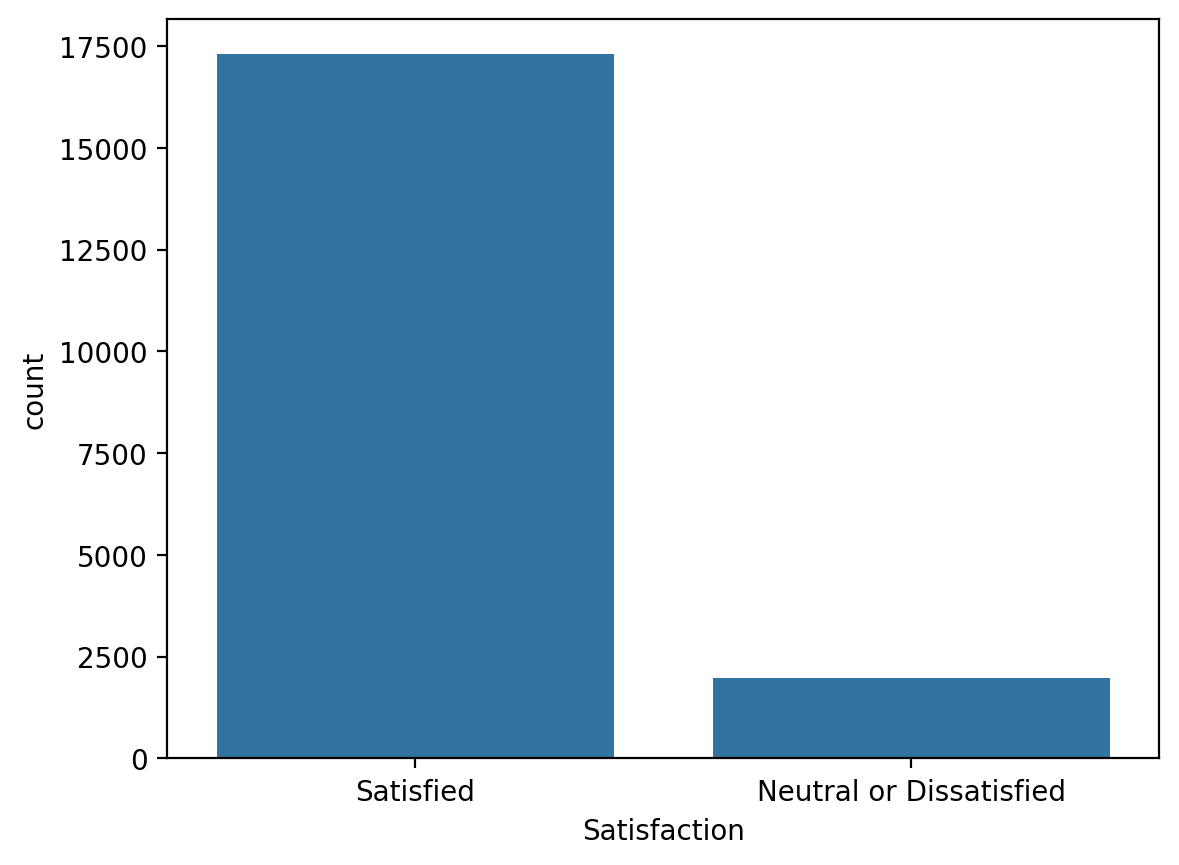

In [9]:
sns.countplot(x='Satisfaction', data=data)

# 의견 : 타겟 변수인 Satisfaction 만족, 불만족 개수의 차이가 심하다는걸 알 수 있었다.

### (3) 결측치 확인

- 결측치 비율을 기준으로 내림차순 정렬해 확인합니다.

In [10]:
missing_ratio = (data.isna().sum() / len(data) * 100).sort_values(ascending=False)

missing_ratio

,0
Age,3.382094
Inflight wifi service,3.309472
Seat comfort,2.526196
Food and drink,1.997095
Arrival Delay in Minutes,0.280112
Customer Type,0.000000
Unnamed: 0,0.000000
Gender,0.000000
ID,0.000000
Flight Distance,0.000000


### (4) 결측치 채우기

- 결측치가 있는 수치형 변수는 **중앙값**으로, 범주형 변수는 **최빈값**으로 채웁니다.
    - 수치형 변수: 'Age', 'Arrival Delay in Minutes'
    - 범주형 변수: 'Inflight wifi service', 'Seat comfort', 'Food and drink'
- 추천: 이후 확장성을 위해 범주형/수치형 변수를 자동 선택하고, 결측치를 일괄 처리합니다.

In [5]:
# 수치형 변수 선택
num_cols = data.select_dtypes(include=['number']).columns

# 결측치 → 중앙값
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

In [6]:
# 범주형 변수 선택
cat_cols = data.select_dtypes(include=['object', 'category']).columns

# 결측치 → 최빈값
data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode())

In [13]:
data.isna().sum()

,0
Unnamed: 0,0
ID,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


### (5) Target 값 변경

- Target인 **Satisfaction** 변수  값을 1과 0으로 변경합니다.
    - 'Satisfied'--> 1,
    - 'Neutral or Dissatisfied' --> 0
- **map()** 메서드를 사용합니다.

In [7]:
data['Satisfaction'] = data['Satisfaction'].map({'Satisfied' : 1, 'Neutral or Dissatisfied' : 0})

In [15]:
print(data['Satisfaction'].unique())

[1 0]


### (6) 불필요한 변수 제거

- 다음 변수는 분석에 의미가 없으므로 제거합니다.
    - 'Unnamed: 0'
    - 'ID'

In [8]:
drop_cols = ['Unnamed: 0', 'ID']

data.drop(drop_cols, axis=1, inplace=True)

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             19278 non-null  object 
 1   Customer Type                      19278 non-null  object 
 2   Age                                19278 non-null  float64
 3   Type of Travel                     19278 non-null  object 
 4   Class                              19278 non-null  object 
 5   Flight Distance                    19278 non-null  int64  
 6   Inflight wifi service              19278 non-null  float64
 7   Departure/Arrival time convenient  19278 non-null  int64  
 8   Ease of Online booking             19278 non-null  int64  
 9   Gate location                      19278 non-null  int64  
 10  Food and drink                     19278 non-null  float64
 11  Online boarding                    19278 non-null  int

## **3. 미션 2: 가설 수립과 검증**

### (1) 가설 수립

- 'ㅇㅇ이면 ㅇㅇ일 것이다' 라는 형식의 가설을 5개 이상 세워봅니다.
- 이후 분석 과정을 통해 수립한 가설을 검증합니다.
- 특히 이변량 분석을 통해 가설을 검증하도록 합니다.

In [ ]:
# 가설 1: 출발/도착 지연 시간이 만족도에 영향을 줄 것이다
# 가설 2: 비행거리가 길어질수록 기내 와이파이 서비스가 만족도를 결정하는데 미치는 영향력이 클 것이다
# 가설 3: 비행 거리가 길어질수록 청결도와 좌석 편안함 점수가 만족도에 끼치는 영향력이 커질 것이다.
# 가설 4: 온라인 예약 편의성 만족도와 온라인 탑승수속 만족도가 높은 승객은 현장 대기시간이 줄어들어 만족도가 더 높을것이다
# 가설 5: 좌석 등급이 높을수록 만족도가 높을것이다

### (2) 단변량 분석

- 5개 이상의 변수에 대한 단변량 분석을 수행합니다.
- 각 분석에 대한 의견을 주석으로 정리합니다.

,count,mean,std,min,25%,50%,75%,max
Arrival Delay in Minutes,19278.0,12.797697,34.490208,0.0,0.0,0.0,9.0,920.0


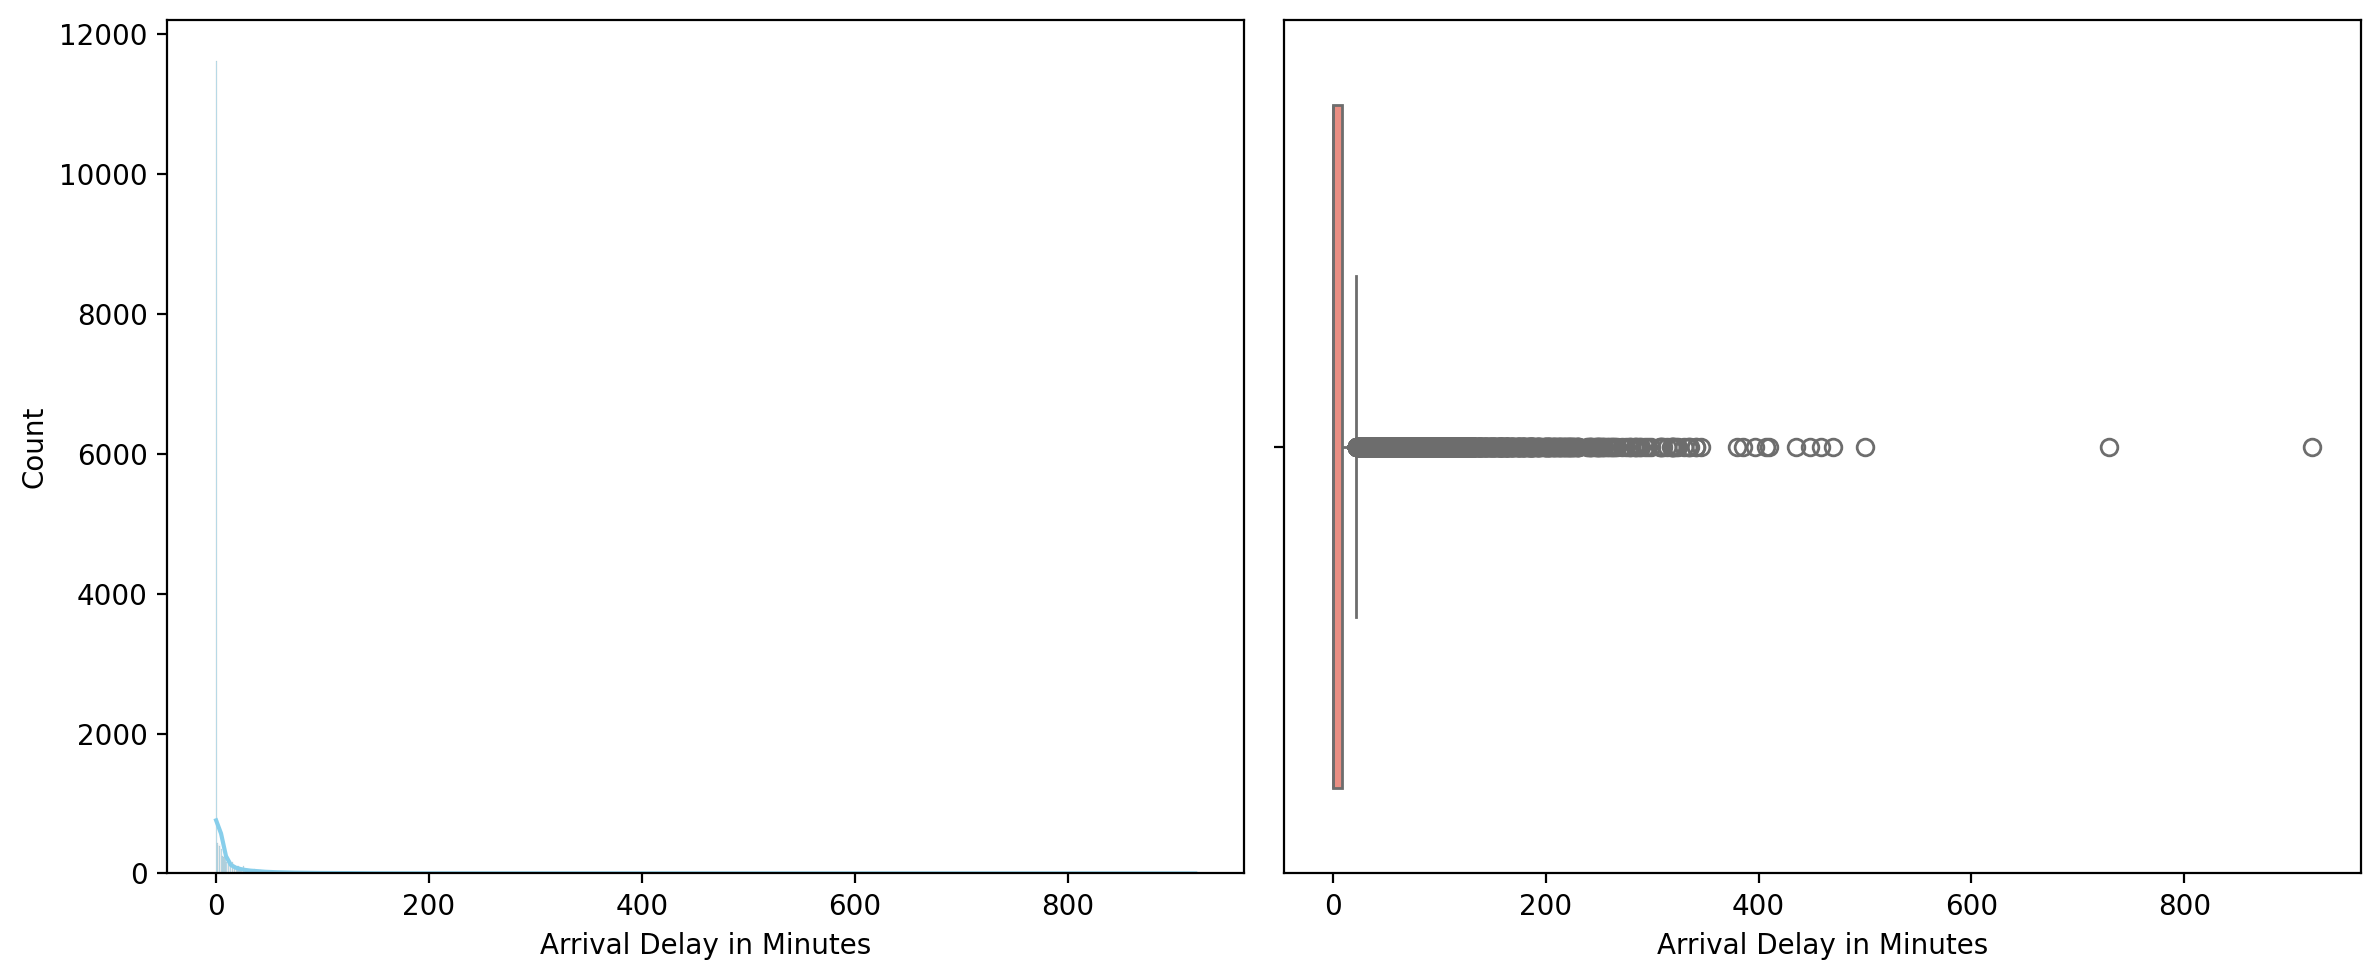

In [30]:
# 도착지연시간 분석
display(data[['Arrival Delay in Minutes']].describe().T)

# 시각화
plt.figure(figsize =(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(x='Arrival Delay in Minutes',data=data, kde=True, color='skyblue')

plt.subplot(1, 2, 2)
sns.boxplot(x='Arrival Delay in Minutes', data=data, color='salmon')

plt.tight_layout()
plt.show()

# 의견: 도착 지연 시간의 중앙값은 0분이며 제3사분위수(75%)가 9분에 불과하여, 전반적인 정시 운항률은 양호함
#       다만, 최대 920분의 극단적 지연 사례가 존재하며 표준편차가 매우 큼. > 이러한 통계적 이상치가 전체 고객 만족도 하락의 결정적 요인(Critical Factor)으로
#       작용할 가능성이 높으므로, 향후 모델링 시 주요하게 다룰 필요가 있음.

,count,mean,std,min,25%,50%,75%,max
Departure Delay in Minutes,19278.0,12.802832,34.104475,0.0,0.0,0.0,9.0,933.0


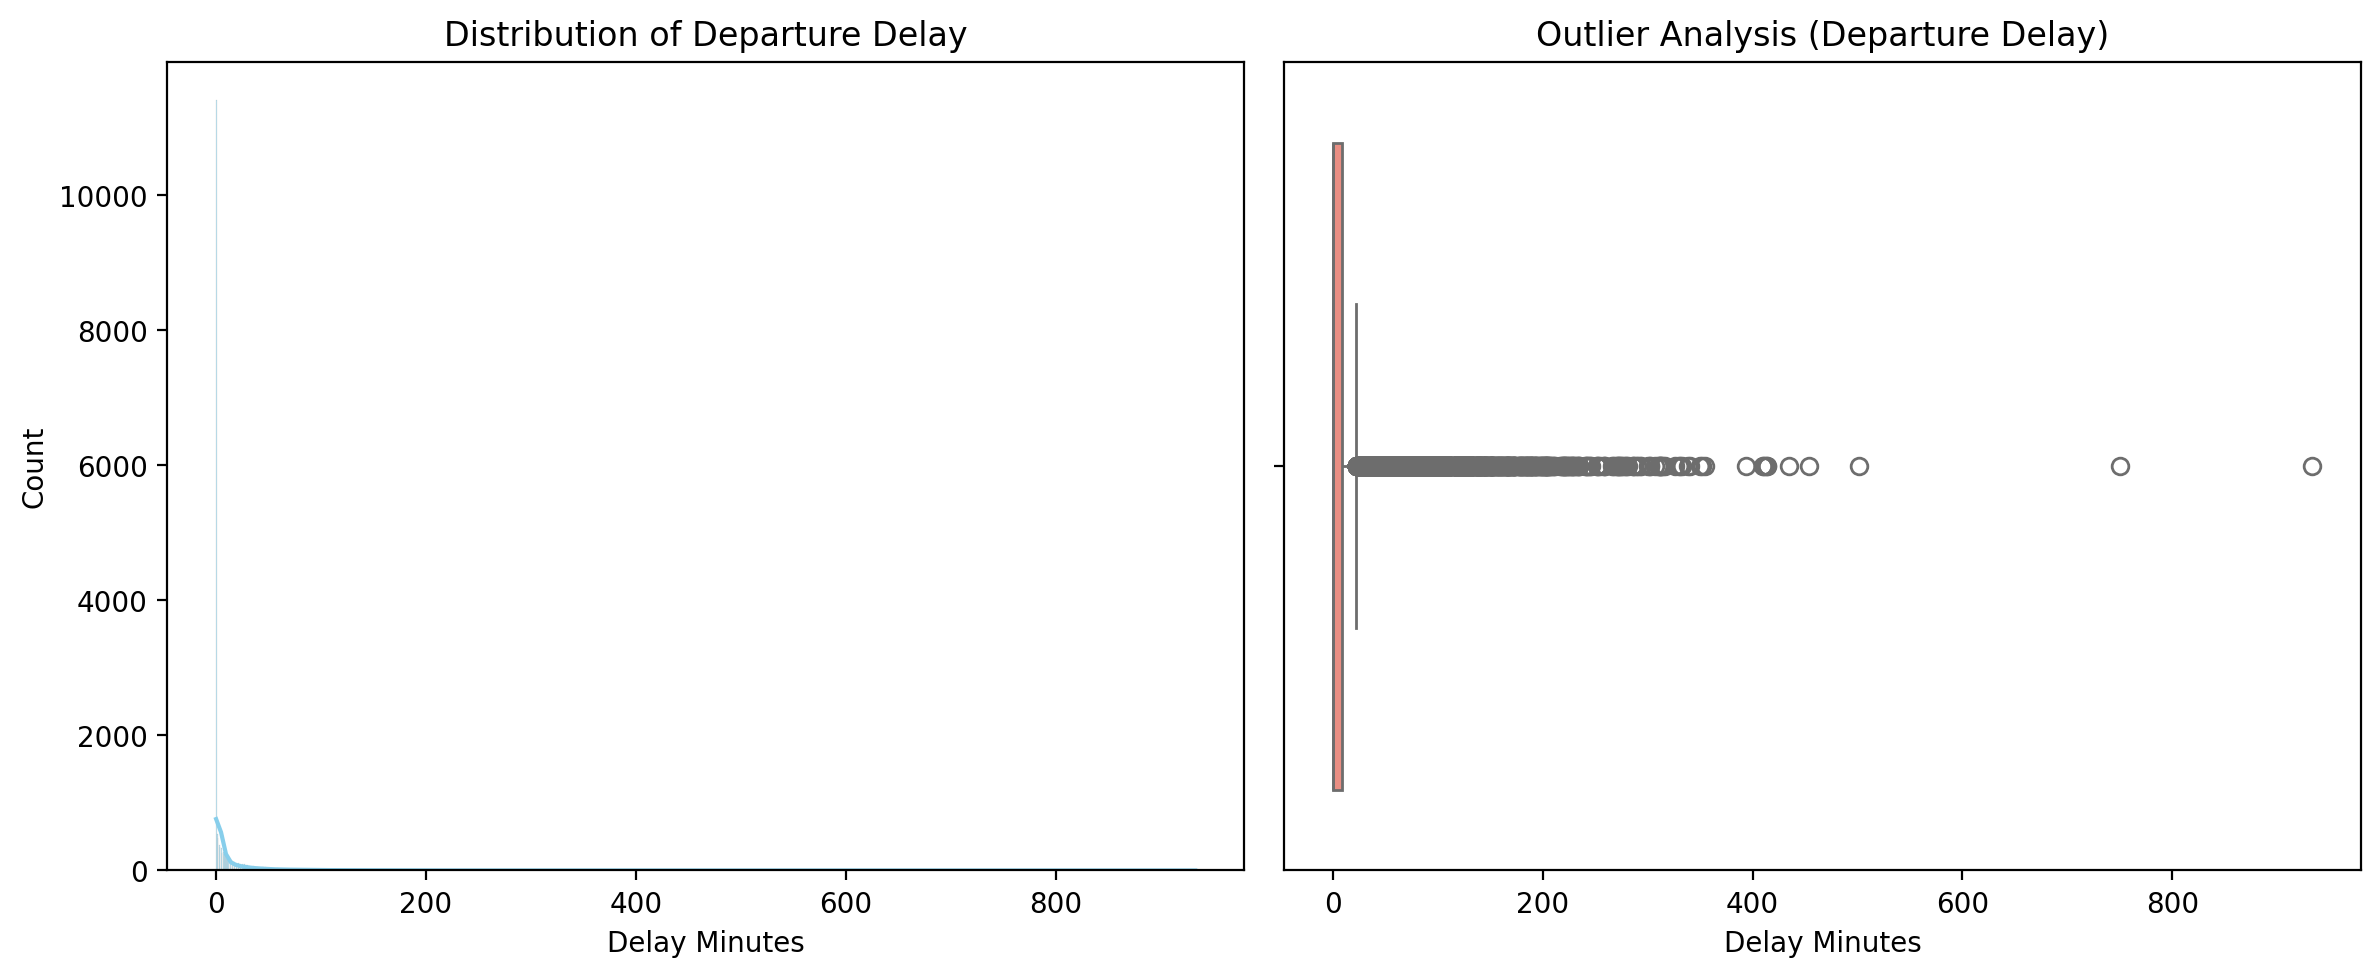

In [26]:
# 출발지연시간 분석
display(data[['Departure Delay in Minutes']].describe().T)

# 시각화
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
sns.histplot(x='Departure Delay in Minutes', data=data, kde=True, color='skyblue')
plt.title('Distribution of Departure Delay')
plt.xlabel('Delay Minutes')


plt.subplot(1, 2, 2)
sns.boxplot(x='Departure Delay in Minutes', data=data, color='salmon')
plt.title('Outlier Analysis (Departure Delay)')
plt.xlabel('Delay Minutes')

plt.tight_layout()
plt.show()

# 의견: 출발 지연 시간의 분석 결과, 75%의 항공편이 9분 이내에 출발하여 기본 정시성은 우수함.
#       하지만 최대 933분에 달하는 극단적 지연 사례들이 다수 존재하며, 이러한 이상치들이 평균 지연 시간을 상승시키고 있음.
#       현장 불만의 주요 원인은 이 극단적 지연 그룹에 집중되어 있을 가능성이 높음.

,count,mean,std,min,25%,50%,75%,max
Flight Distance,19278.0,1474.563544,1117.574556,56.0,495.0,1119.0,2321.0,4983.0


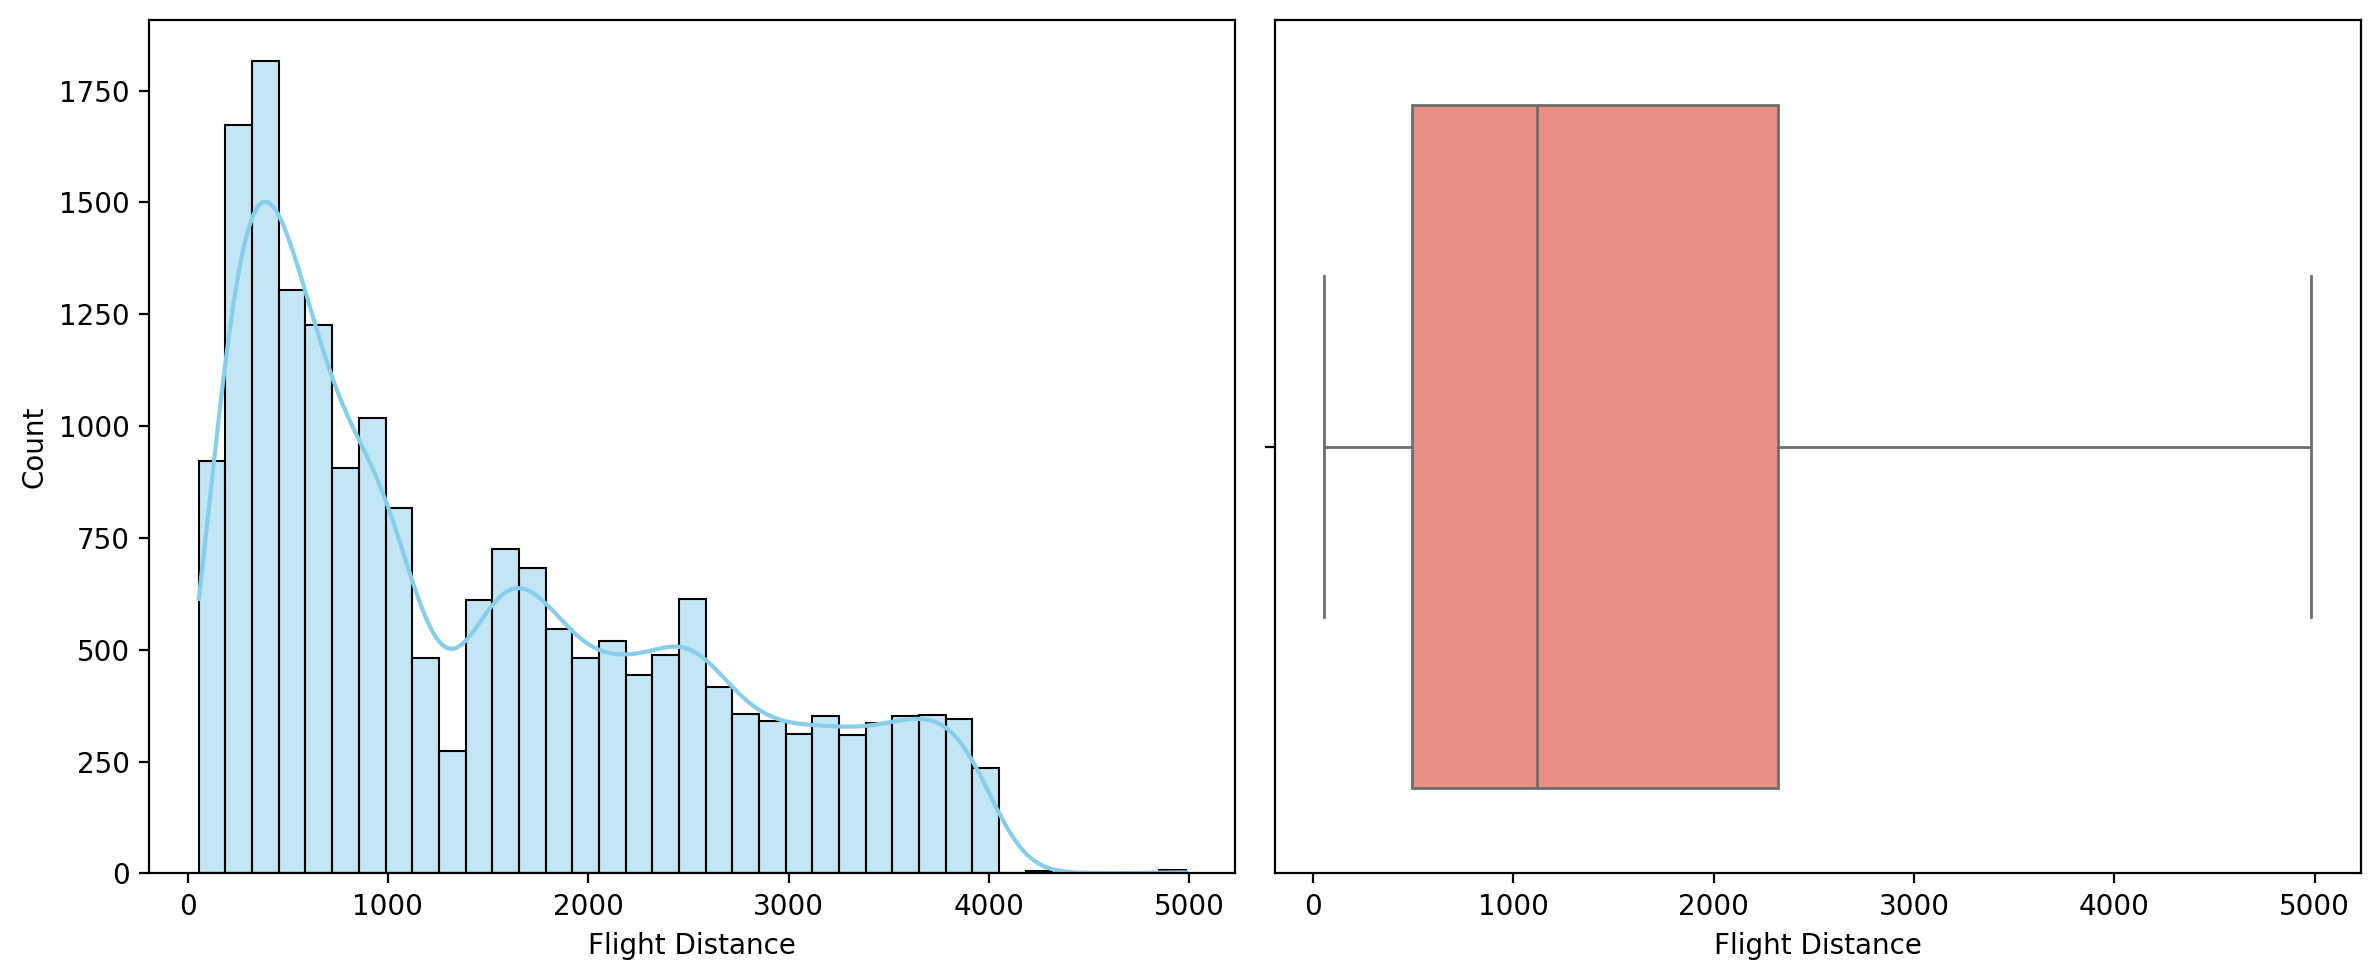

In [32]:
# 비행거리 분석
display(data[['Flight Distance']].describe().T)

# 시각화
plt.figure(figsize =(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(x='Flight Distance', data=data, kde=True, color='skyblue')

plt.subplot(1, 2, 2)
sns.boxplot(x='Flight Distance', data=data, color='salmon')

plt.tight_layout()
plt.show()

# 의견: 우리 항공사의 승객은 1,000km 미만의 단거리 승객과 2,500km 전후의 중거리 승객으로 양분됨.
#       특히 단거리 승객은 '정시성(지연 여부)'에 민감할 가능성이 크고,
#       중거리 이상 승객은 우리가 세운 가설처럼 '기내 와이파이'나 '좌석 편안함'에 대한 불만이 현장에서 터져 나올 가능성이 높음

Class
Business    0.714908
Eco         0.239081
Eco Plus    0.046011
Name: count, dtype: float64


<Axes: xlabel='Class', ylabel='count'>

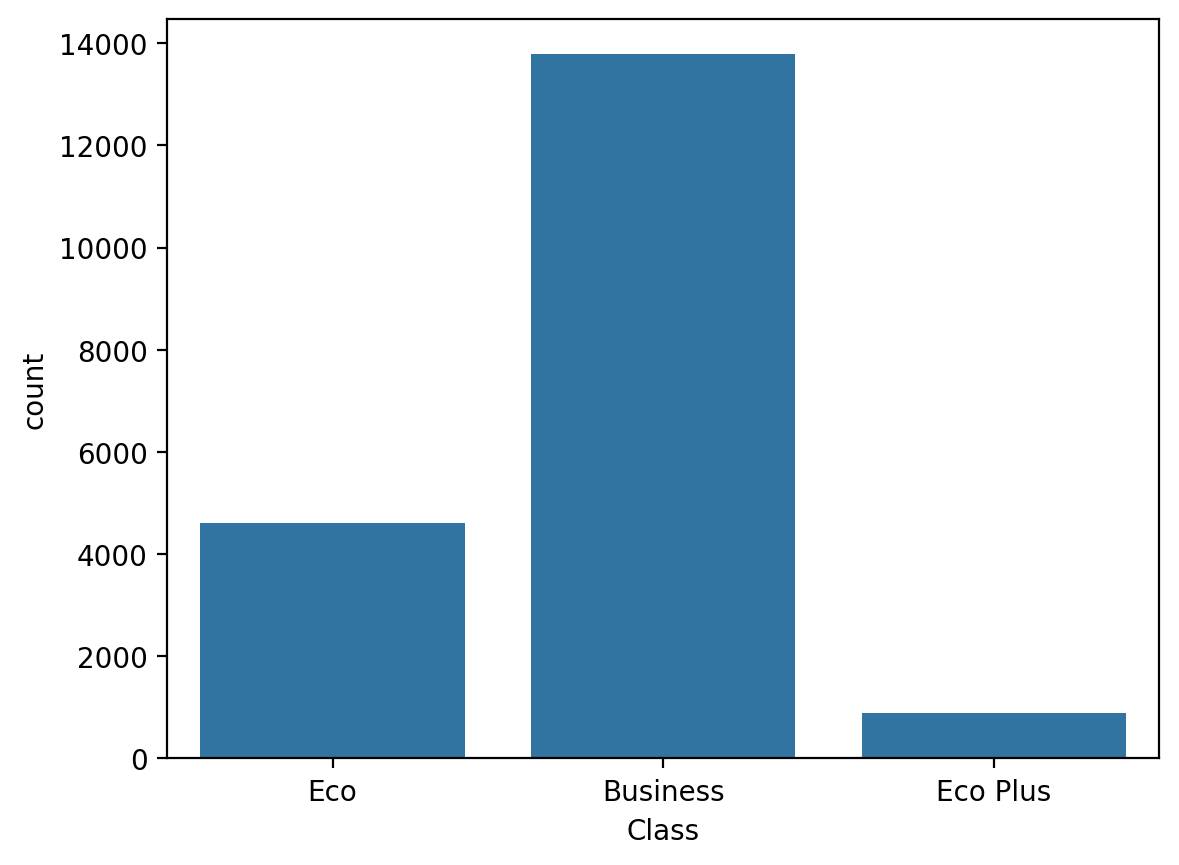

In [35]:
# 클래스 분석
temp = data['Class'].value_counts()

print(temp/len(data))

# 시각화
sns.countplot(x='Class', data=data)

# 의견 : 전체 승객의 71.5%가 Business 클래스에 집중되어 있어, 전반적인 설문 만족도 점수가 상향 평준화되었을 가능성이 큼. 비즈니스 승객 특유의 높은 서비스 기대치를 고려할 때, 시설 만족도와는 별개로
#        '인적 서비스'나 '정시성' 등의 요인이 현장 불만을 야기하는 핵심 포인트일 것으로 판단됨

Customer Type
Loyal Customer       0.88697
Disloyal Customer    0.11303
Name: count, dtype: float64


<Axes: xlabel='Customer Type', ylabel='count'>

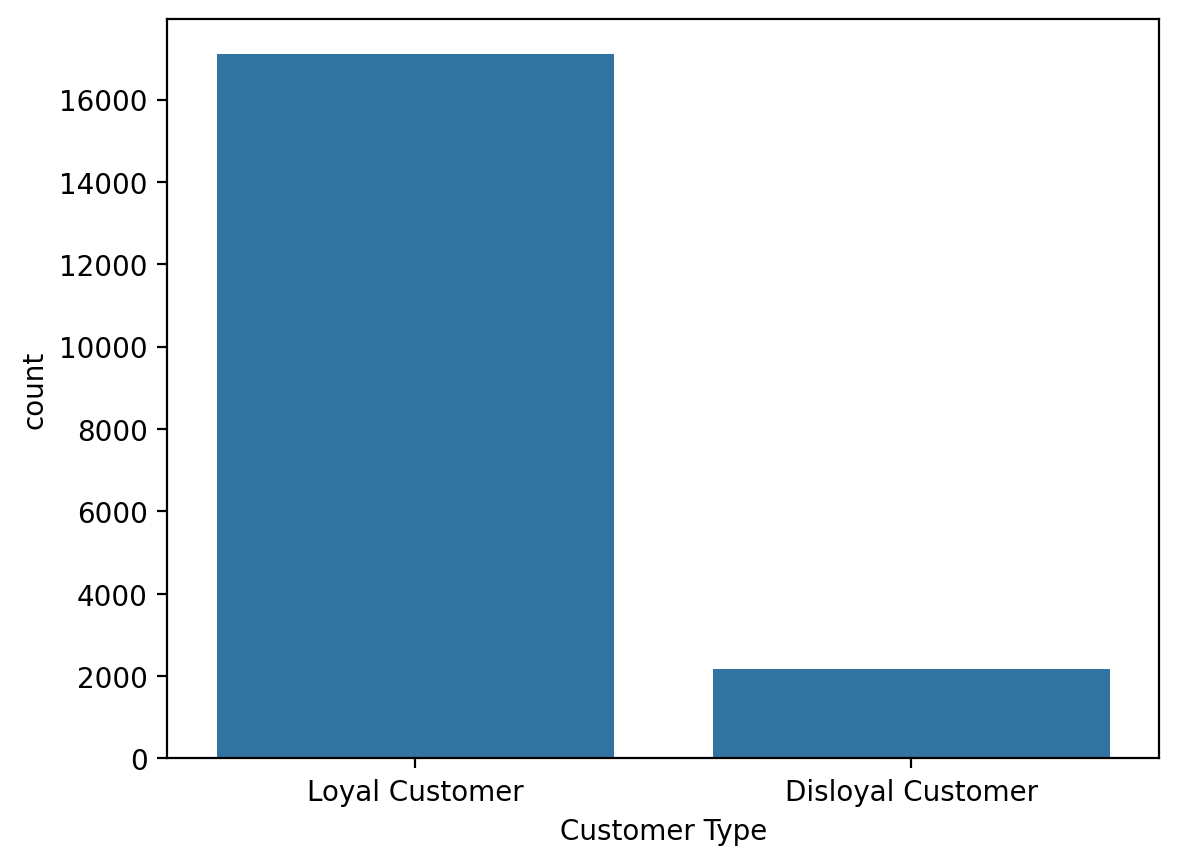

In [36]:
# 고객 유형 분석
temp = data['Customer Type'].value_counts()

print(temp/len(data))

# 시각화
sns.countplot(x='Customer Type', data=data)

# 의견 : 전체 승객의 약 89%가 충성 고객(Loyal Customer)으로 구성되어 있어, 기본적으로 우호적인 설문 결과가 도출되기 쉬운 구조임.
#        그러나 현장 불만이 지속적으로 제기된다는 것은 핵심 고객층인 충성 고객들의 '기대 서비스 수준'과 '실제 경험' 사이의 괴리가 발생했음을 의미함

Type of Travel
Business Travel    0.884998
Personal Travel    0.115002
Name: count, dtype: float64


<Axes: xlabel='Type of Travel', ylabel='count'>

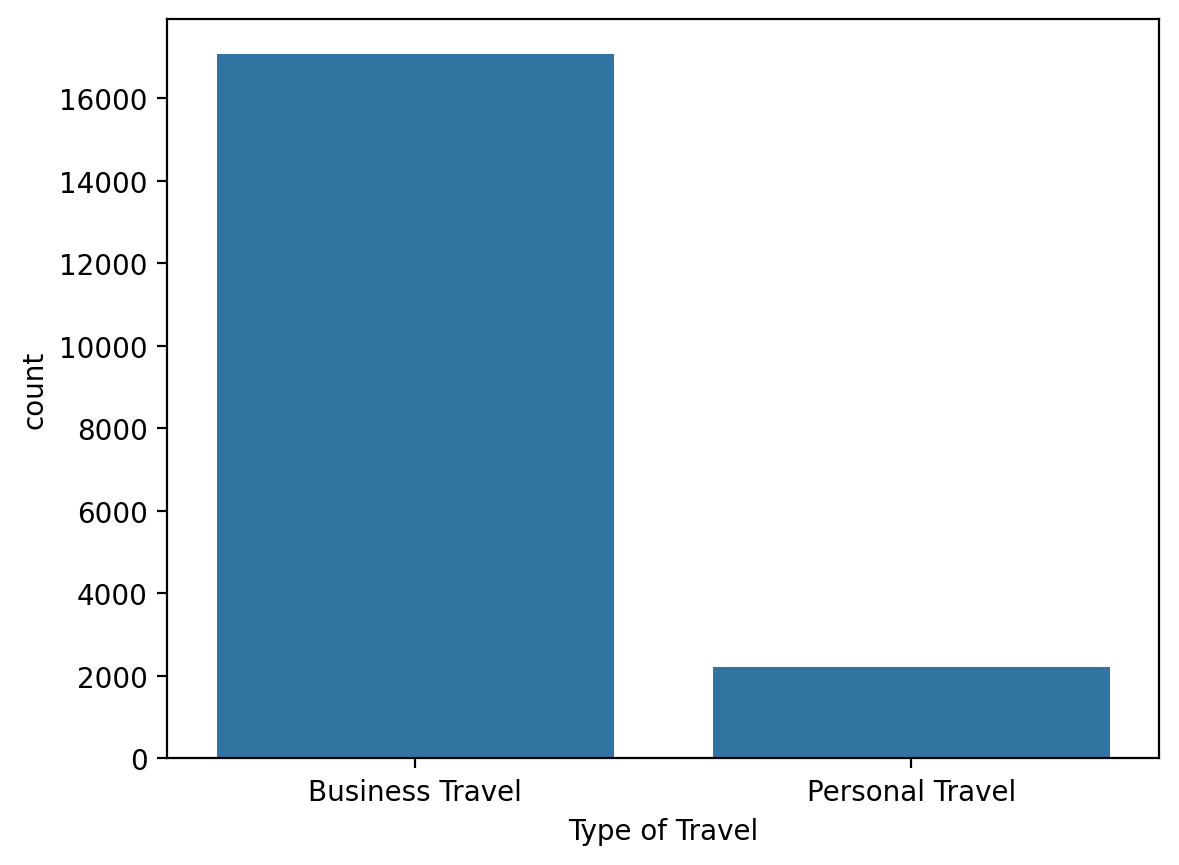

In [37]:
# 여행 목적 분석
temp = data['Type of Travel'].value_counts()

print(temp/len(data))

# 시각화
sns.countplot(x='Type of Travel', data=data)

# 의견 : 데이터의 88%를 차지하는 비즈니스 여행객의 특성상, 즐거움보다는 '효율성'과 '정시성'이 만족도의 핵심 지표일 것으로 추측됨.
#        특히 업무 연속성을 위한 기내 와이파이 품질이나, 피로를 줄여주는 온라인 체크인 편의성 등이 실제 만족도 모델에서 높은 가중치를 가질 것으로 가설을 세울 수 있음.

In [ ]:
# 분석 결과, 타겟 변수인 만족도(약 9:1)를 포함하여 여행 목적(Business), 고객 유형(Loyal), 클래스(Business) 등 주요 변수들이
# 특정 범주에 강하게 치우친 데이터 불균형(Class Imbalance) 현상이 관찰됨
# 이러한 불균형 데이터는 학습 시 다수 클래스에 편향된 결과를 낼 수 있으므로, 향후 모델링 단계에서 소수 그룹에 대한 예측력을 보완할 필요가 있음

### (3) 이변량 분석

- 5개 이상의 이변량 분석을 수행합니다.
- 각 분석에 대한 의견을 주석으로 정리합니다.

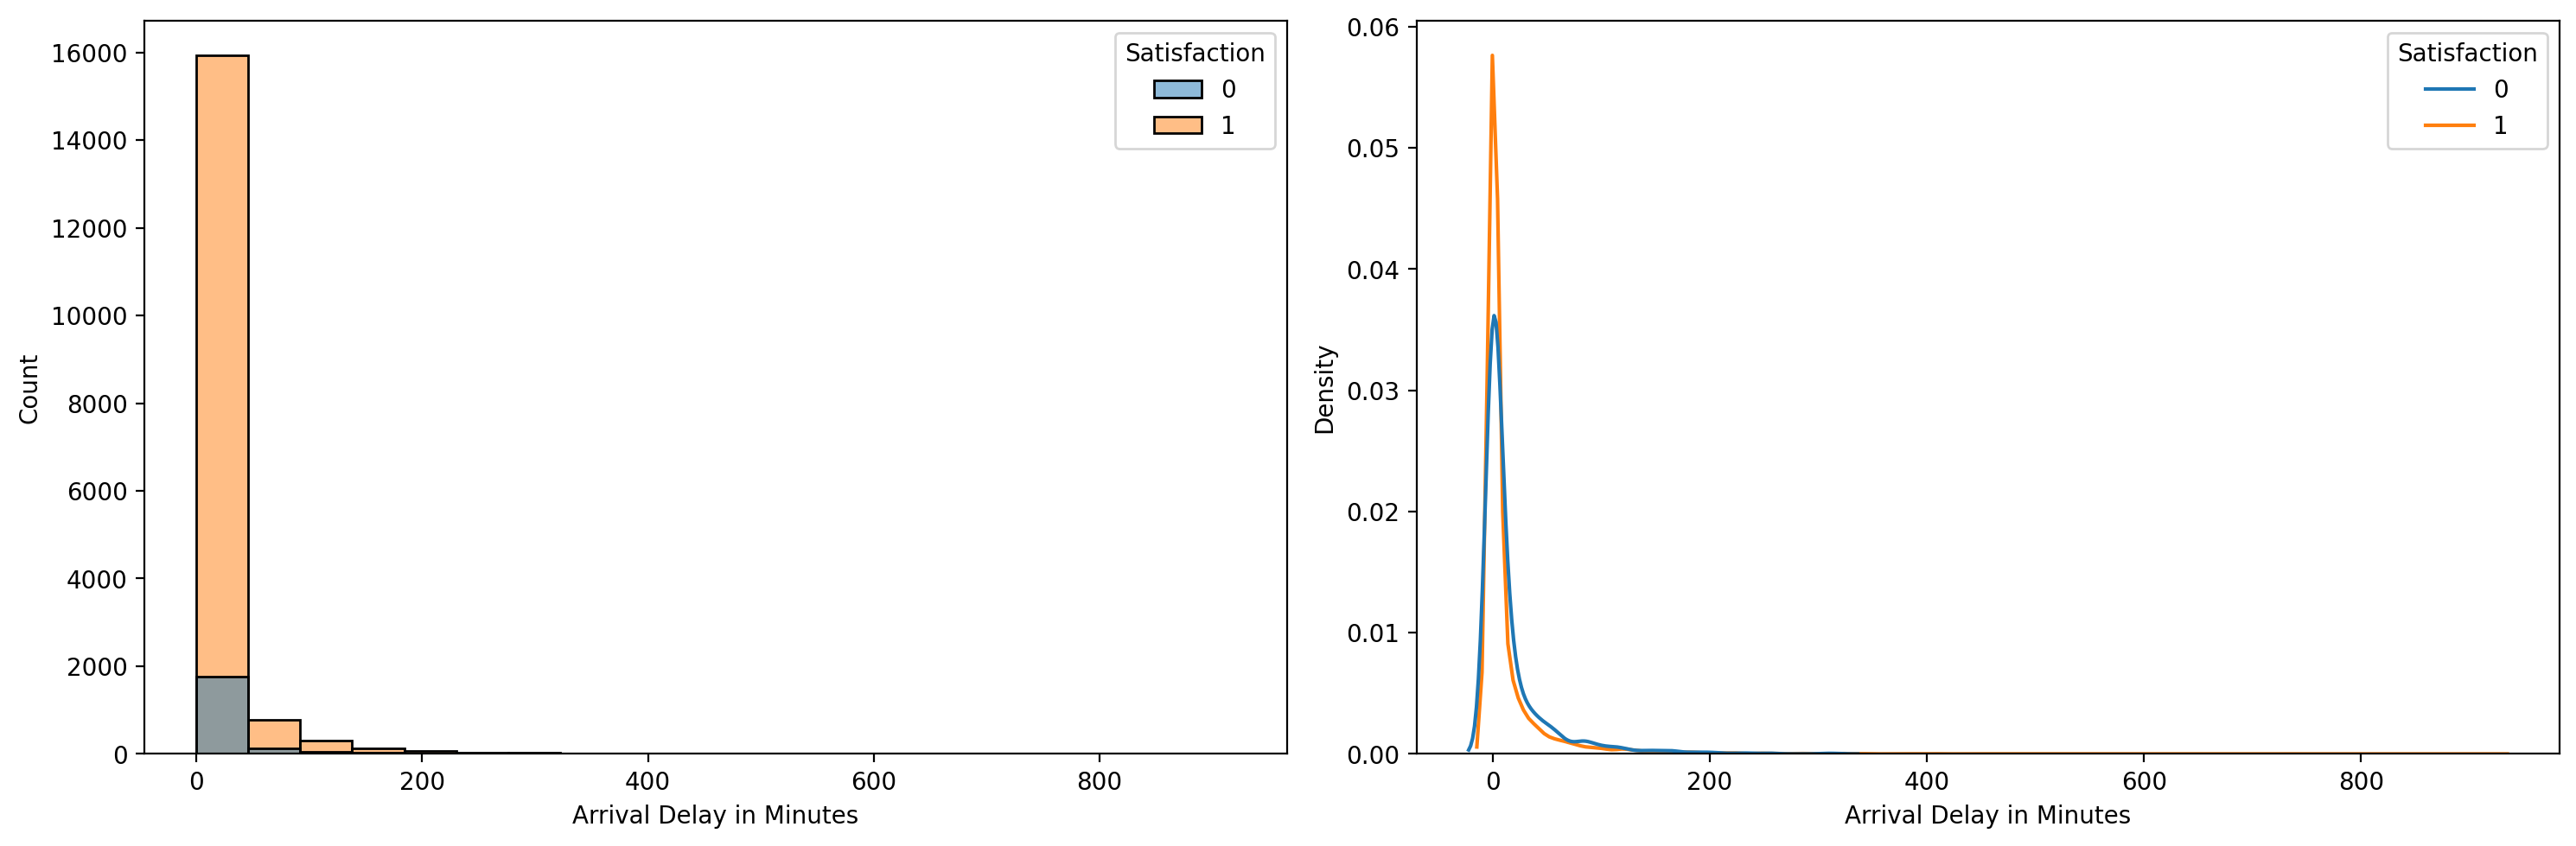

Optimization terminated successfully.
         Current function value: 0.331122
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           Satisfaction   No. Observations:                19278
Model:                          Logit   Df Residuals:                    19276
Method:                           MLE   Df Model:                            1
Date:                Mon, 04 May 2026   Pseudo R-squ.:                0.001303
Time:                        17:36:32   Log-Likelihood:                -6383.4
converged:                       True   LL-Null:                       -6391.7
Covariance Type:            nonrobust   LLR p-value:                 4.467e-05
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        2.1993      0.025     86.980      0.000       2.150

In [40]:
# 도착지연시간 -> 만족도
import statsmodels.api as sm

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(x='Arrival Delay in Minutes', hue='Satisfaction', data=data, bins=20)

plt.subplot(1, 2, 2)
sns.kdeplot(x='Arrival Delay in Minutes', hue='Satisfaction', data=data, common_norm=False)

plt.tight_layout()
plt.show()

# 1. 독립변수(x)와 종속변수(y) 설정
# 원인: 지연 시간, 결과: 만족도(0 또는 1)
target = data['Satisfaction']
features = data['Arrival Delay in Minutes']

# 2. 상수항 추가 (필수!)
features = sm.add_constant(features)

# 3. 로지스틱 회귀 모델 생성 및 학습
model = sm.Logit(target, features)
result = model.fit()

# 4. 결과 출력
print(result.summary())

# 의견: 도착 지연 시간은 만족도와 유의미한 음(-)의 상관관계(p < 0.05)를 보이며, 정시 도착 시 만족도가 극대화되나 지연 발생 즉시 불만족 비율이 가파르게 상승하는 높은 민감도를 나타냄.
#       특히 KDE 분포 상 100분 이상의 장기 지연 구간은 불만족 그룹의 밀도가 압도적으로 높아, 이러한 극단적 지연 사례가 브랜드 충성도 하락의 결정적 요인이 될 것으로 예측됨.
#       따라서 모델링 시 지연 시간을 핵심 변수로 활용하되, 현장 운영 측면에서는 미세 지연 방지보다 장기 지연 리스크를 최소화하는 관리 전략이 시급함

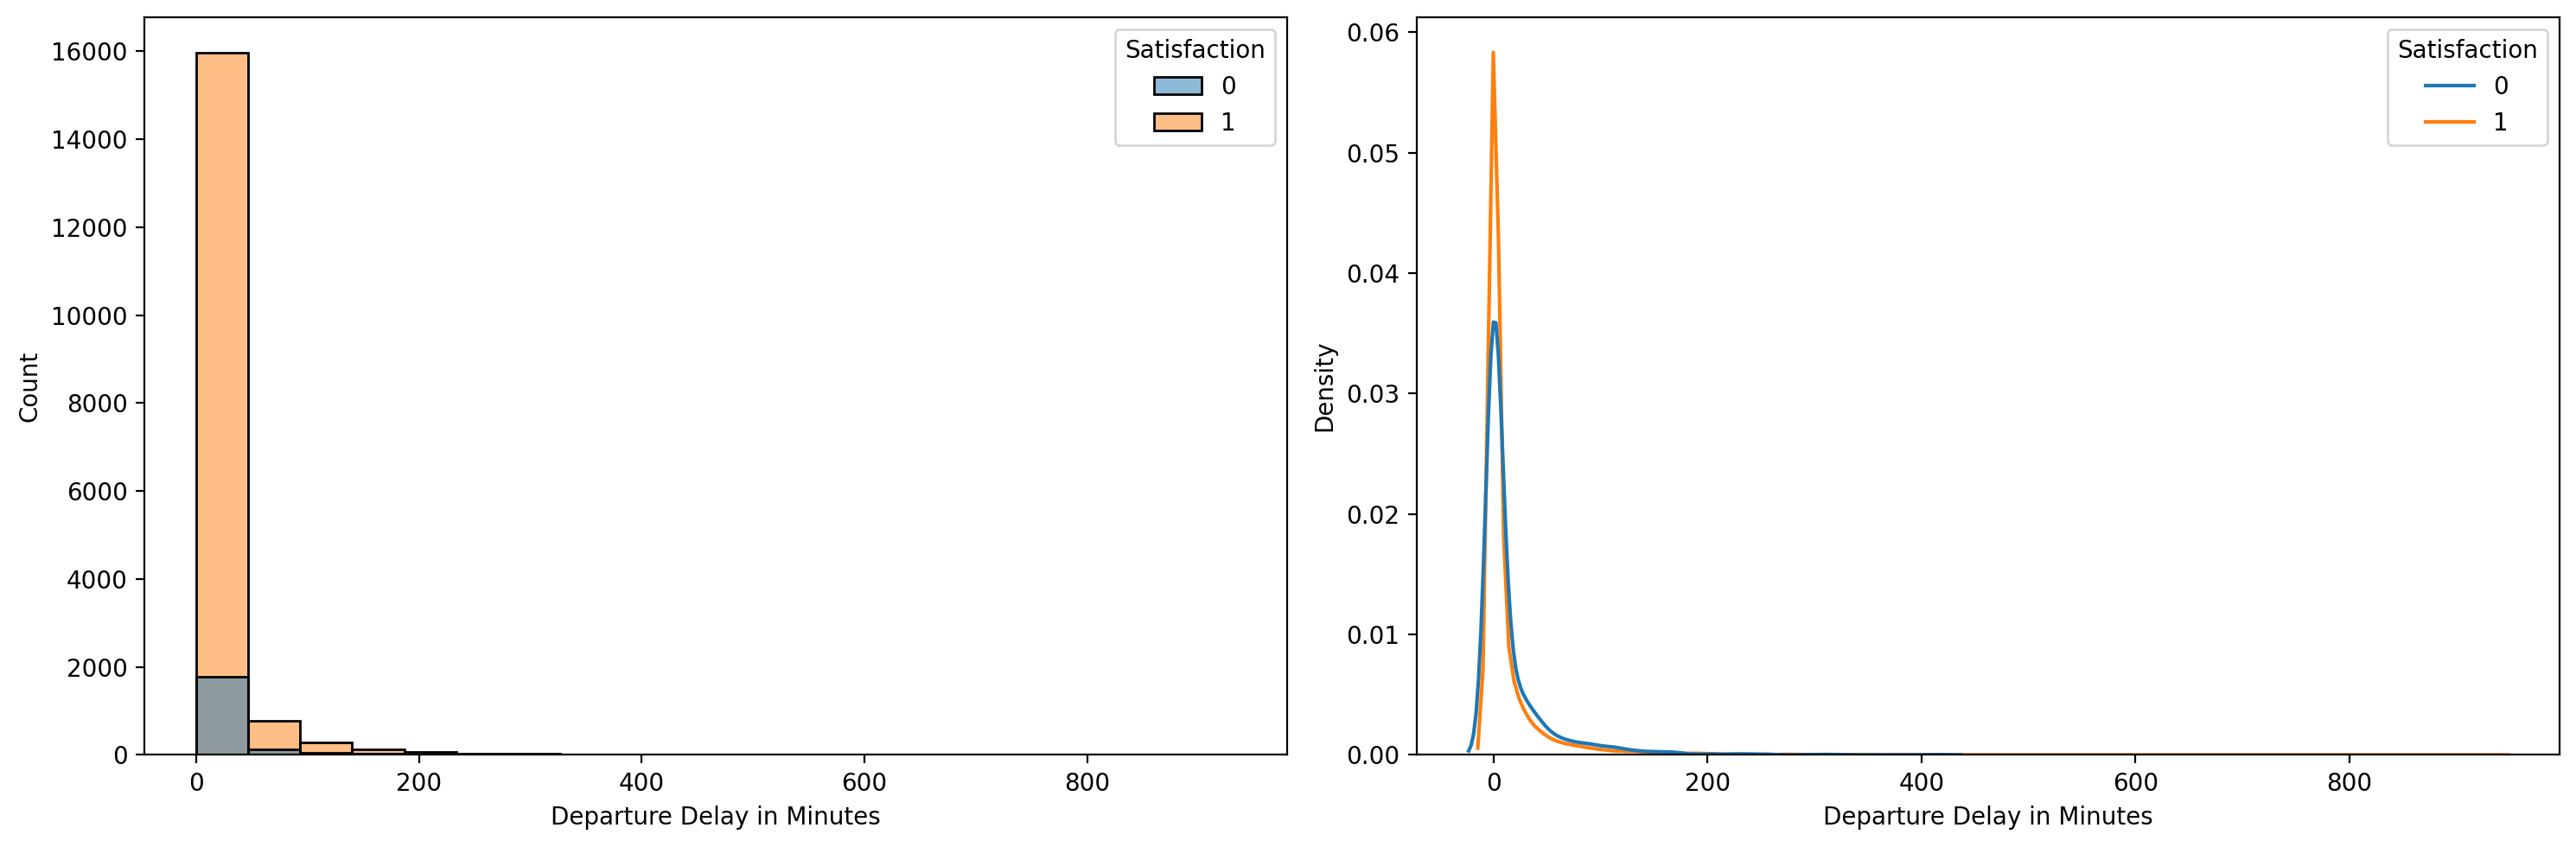

Optimization terminated successfully.
         Current function value: 0.331162
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           Satisfaction   No. Observations:                19278
Model:                          Logit   Df Residuals:                    19276
Method:                           MLE   Df Model:                            1
Date:                Mon, 04 May 2026   Pseudo R-squ.:                0.001182
Time:                        17:50:45   Log-Likelihood:                -6384.1
converged:                       True   LL-Null:                       -6391.7
Covariance Type:            nonrobust   LLR p-value:                 0.0001013
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          2.1980      0.025     86.858      0.000      

In [41]:
# 출발지연시간 -> 만족도
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(x='Departure Delay in Minutes', hue='Satisfaction', data=data, bins=20)

plt.subplot(1, 2, 2)
sns.kdeplot(x='Departure Delay in Minutes', hue='Satisfaction', data=data, common_norm=False)

plt.tight_layout()
plt.show()

# 1. 독립변수(x)와 종속변수(y) 설정
# 원인: 지연 시간, 결과: 만족도(0 또는 1)
target = data['Satisfaction']
features = data['Departure Delay in Minutes']

# 2. 상수항 추가 (필수!)
features = sm.add_constant(features)

# 3. 로지스틱 회귀 모델 생성 및 학습
model = sm.Logit(target, features)
result = model.fit()

# 4. 결과 출력
print(result.summary())

# 의견: 로지스틱 회귀 분석 결과, 출발 지연 시간은 고객 만족도와 통계적으로 유의미한 음(-)의 상관관계($p < 0.05$)를 보이며 지연 시간이 늘어날수록 만족도 확률을 지속적으로 하락시킴.
#       대다수 승객이 정시 출발 시 높은 만족도를 보이나, KDE 분포상 불만족 그룹은 만족 그룹에 비해 100분 이상의 장기 지연 구간에 두껍게 분포하여 극단적 지연이 고객 이탈의 결정적 원인임을 시사함.
#       따라서 전체 평균을 왜곡하는 장기 지연 사례를 모델링의 주요 관리 대상으로 설정하고, 해당 이상치 발생 시의 서비스 보상 전략 수립이 필수적임.

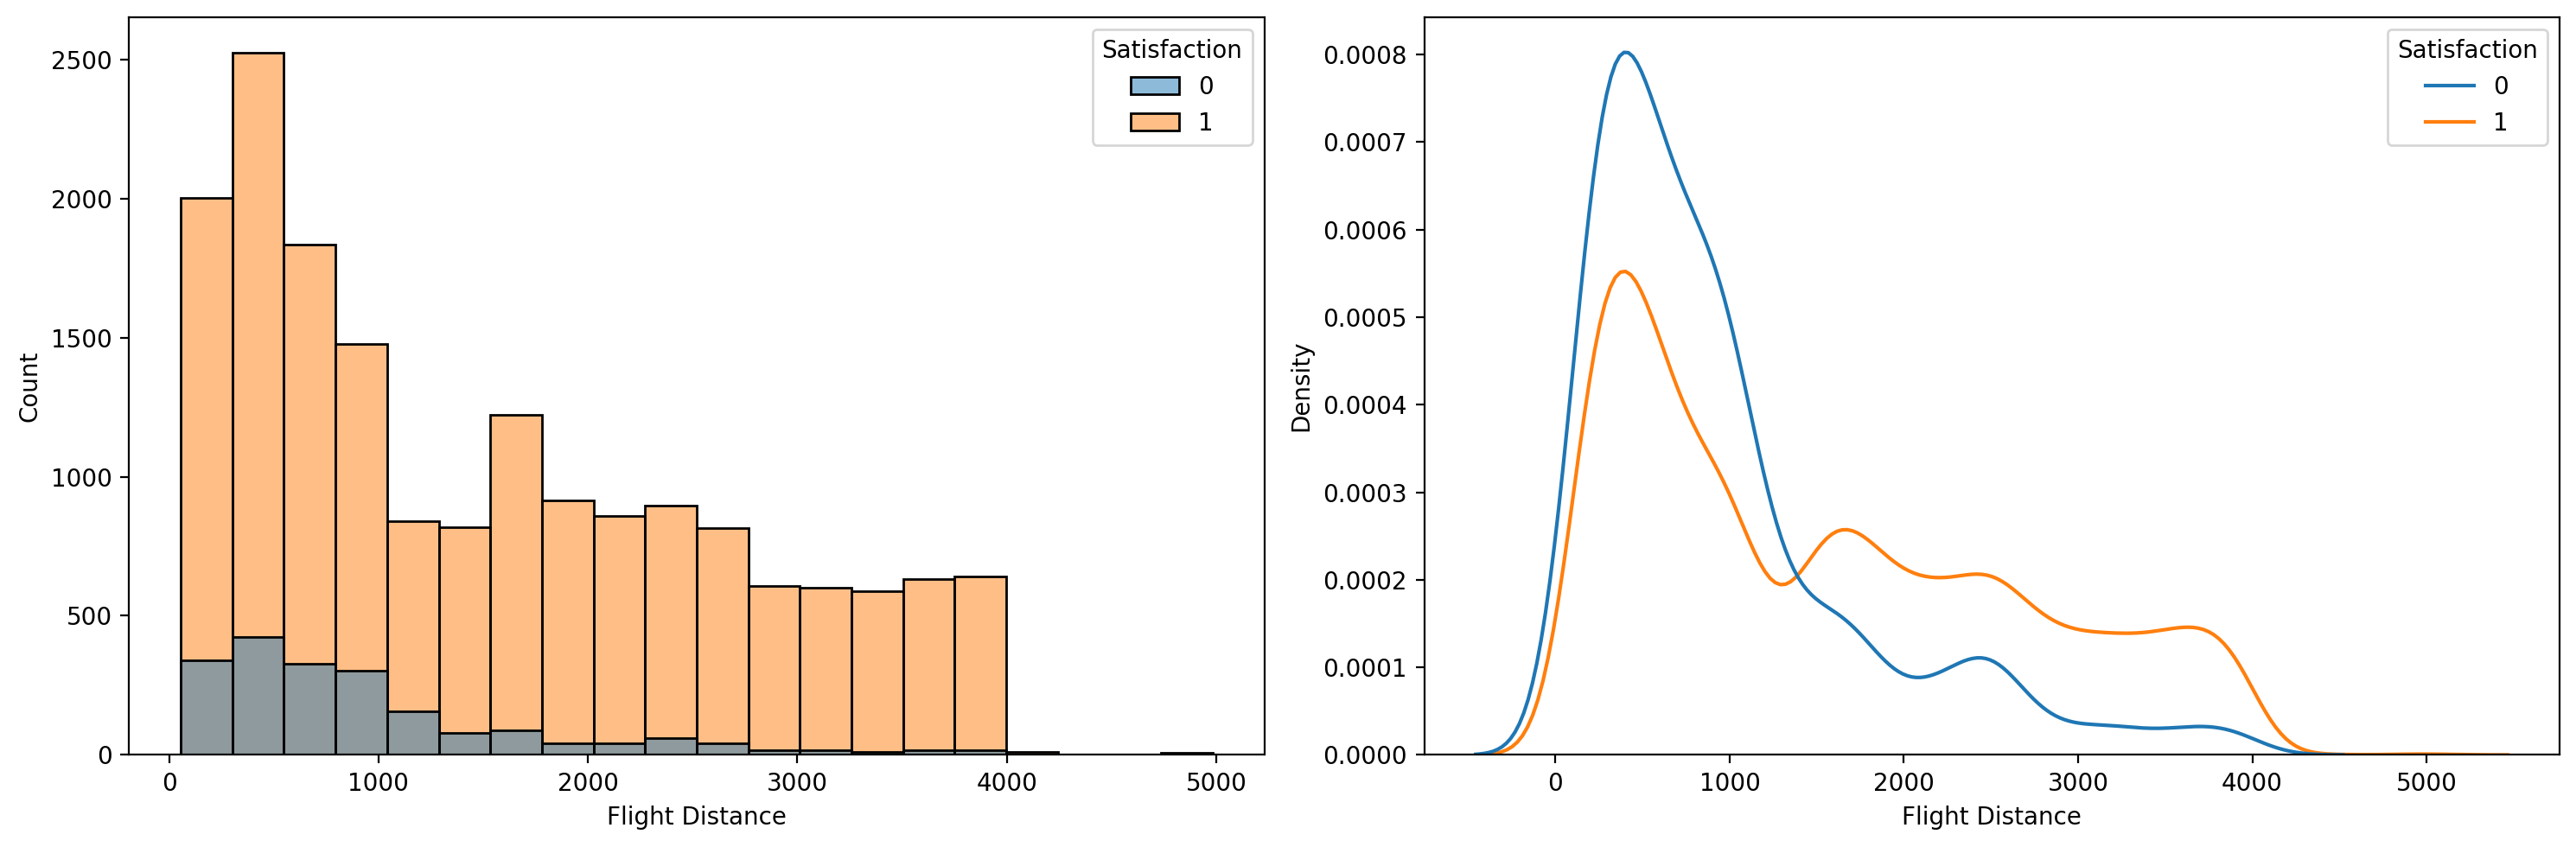

Optimization terminated successfully.
         Current function value: 0.316653
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           Satisfaction   No. Observations:                19278
Model:                          Logit   Df Residuals:                    19276
Method:                           MLE   Df Model:                            1
Date:                Mon, 04 May 2026   Pseudo R-squ.:                 0.04494
Time:                        17:50:51   Log-Likelihood:                -6104.4
converged:                       True   LL-Null:                       -6391.7
Covariance Type:            nonrobust   LLR p-value:                5.829e-127
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.4393      0.036     39.439      0.000       1.368       1.511
Flight Distanc

In [42]:
# 비행거리 -> 만족도
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(x='Flight Distance', hue='Satisfaction', data=data, bins=20)

plt.subplot(1, 2, 2)
sns.kdeplot(x='Flight Distance', hue='Satisfaction', data=data, common_norm=False)

plt.tight_layout()
plt.show()

# 1. 독립변수(x)와 종속변수(y) 설정
# 원인: 지연 시간, 결과: 만족도(0 또는 1)
target = data['Satisfaction']
features = data['Flight Distance']

# 2. 상수항 추가 (필수!)
features = sm.add_constant(features)

# 3. 로지스틱 회귀 모델 생성 및 학습
model = sm.Logit(target, features)
result = model.fit()

# 4. 결과 출력
print(result.summary())

# 의견: 비행 거리가 늘어날수록 전반적인 만족 확률은 유의미하게 상승하나, 불만족 그룹의 분포가 1,000km 미만 단거리 구간에 매우 조밀하게 밀집되어 있음.
#       이는 우리 항공사의 불만족 경험이 주로 단거리 노선에서 발생하고 있음을 시사하며, 단거리 노선에서의 정시성이나 서비스 품질 개선이 최우선 과제임을 보여줌.

Satisfaction,0,1
Class,,
Business,528,13254
Eco,1265,3344
Eco Plus,192,695


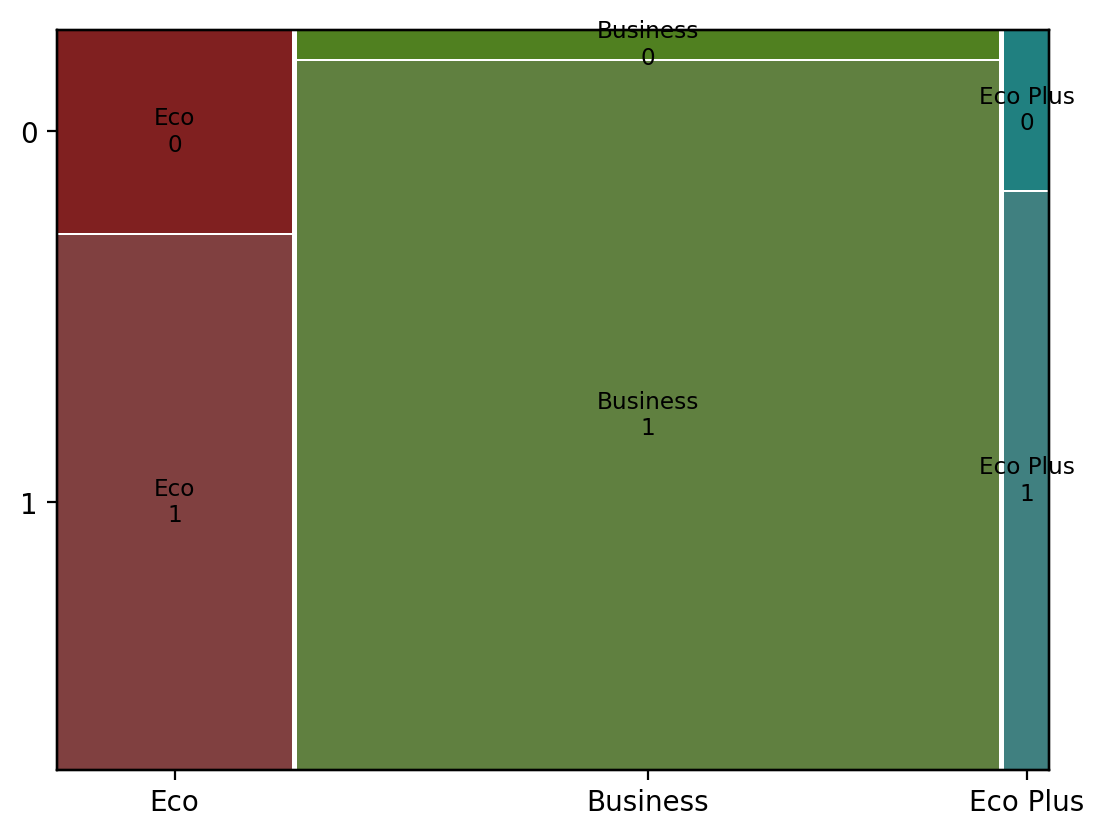

* 카이제곱통계량: 2215.06713602404
* p-value: 0.0
* 기대빈도:
 [[ 1419.09274821 12362.90725179]
 [  474.57542276  4134.42457724]
 [   91.33182903   795.66817097]]


In [43]:
# 좌석등급 -> 만족도
from statsmodels.graphics.mosaicplot import mosaic
import scipy.stats as spst

table = pd.crosstab(data['Class'], data['Satisfaction'])
display(table)

mosaic(data, ['Class', 'Satisfaction'])
plt.show()

result = spst.chi2_contingency(table)
print('* 카이제곱통계량:', result[0])
print('* p-value:', result[1])
print('* 기대빈도:\n',result[3])

# 의견 : 카이제곱 검정 결과, 좌석 등급과 만족도는 매우 강력한 통계적 유의성을 보이며, 특히 Business 클래스의 만족 비율이 타 등급 대비 압도적으로 높게 나타남.
#        반면 Eco 클래스는 전체 불만족 사례의 약 63.8%를 차지하며 서비스 품질 개선이 시급한 핵심 타겟임을 보여줌

Satisfaction,0,1
Customer Type,,
Disloyal Customer,485,1694
Loyal Customer,1500,15599


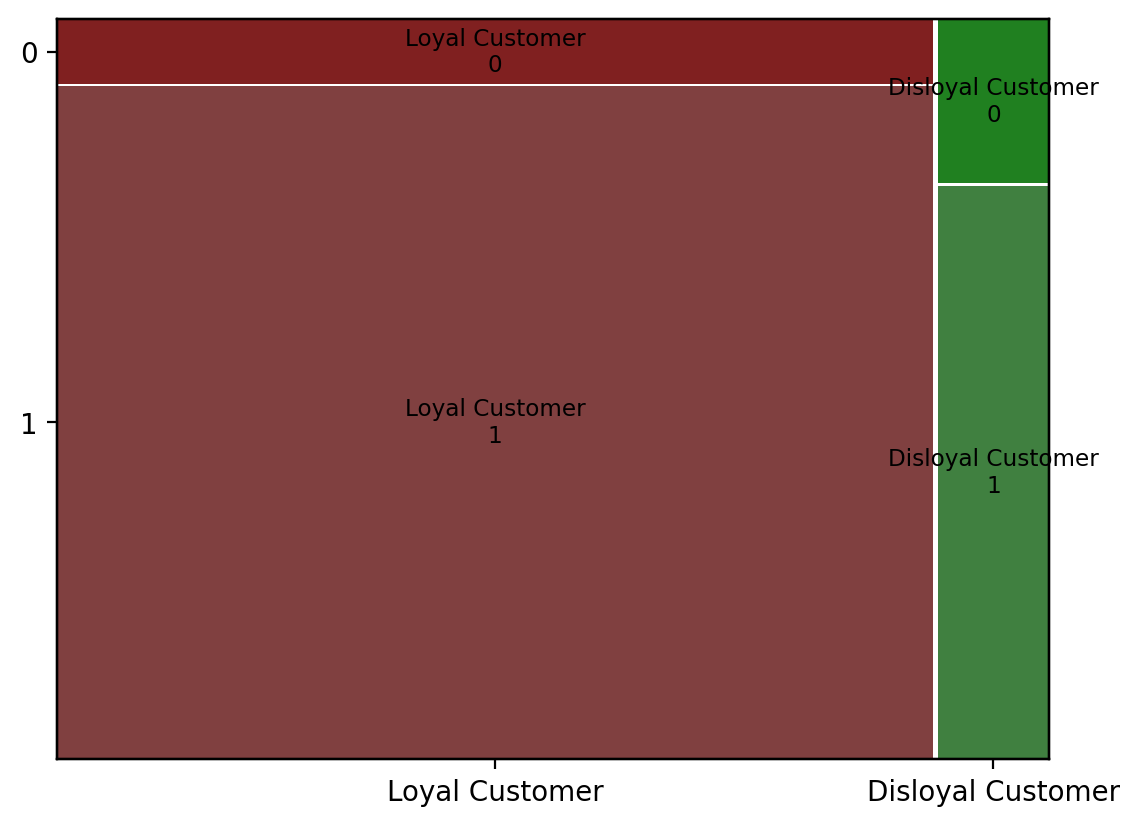

* 카이제곱통계량: 379.0736340119114
* p-value: 1.979913947477063e-84
* 기대빈도:
 [[  224.36533873  1954.63466127]
 [ 1760.63466127 15338.36533873]]


In [44]:
# 승객 유형 -> 만족도
from statsmodels.graphics.mosaicplot import mosaic

table = pd.crosstab(data['Customer Type'], data['Satisfaction'])
display(table)

mosaic(data, ['Customer Type', 'Satisfaction'])
plt.show()

result = spst.chi2_contingency(table)
print('* 카이제곱통계량:', result[0])
print('* p-value:', result[1])
print('* 기대빈도:\n',result[3])
# 의견 : 카이제곱 검정 결과, 고객의 충성도 여부는 만족도에 유의미한 영향을 미치며, 비충성 고객(Disloyal)의 불만족율이 충성 고객 대비 2.5배 이상 높게 나타남.
#        이는 비충성 고객군이 서비스 장애(지연 등)나 기내 서비스 품질에 훨씬 더 민감하게 반응하며, 작은 부정적 경험에도 쉽게 불만족으로 돌아설 수 있음을 시사함

Satisfaction,0,1
Type of Travel,,
Business Travel,1012,16049
Personal Travel,973,1244


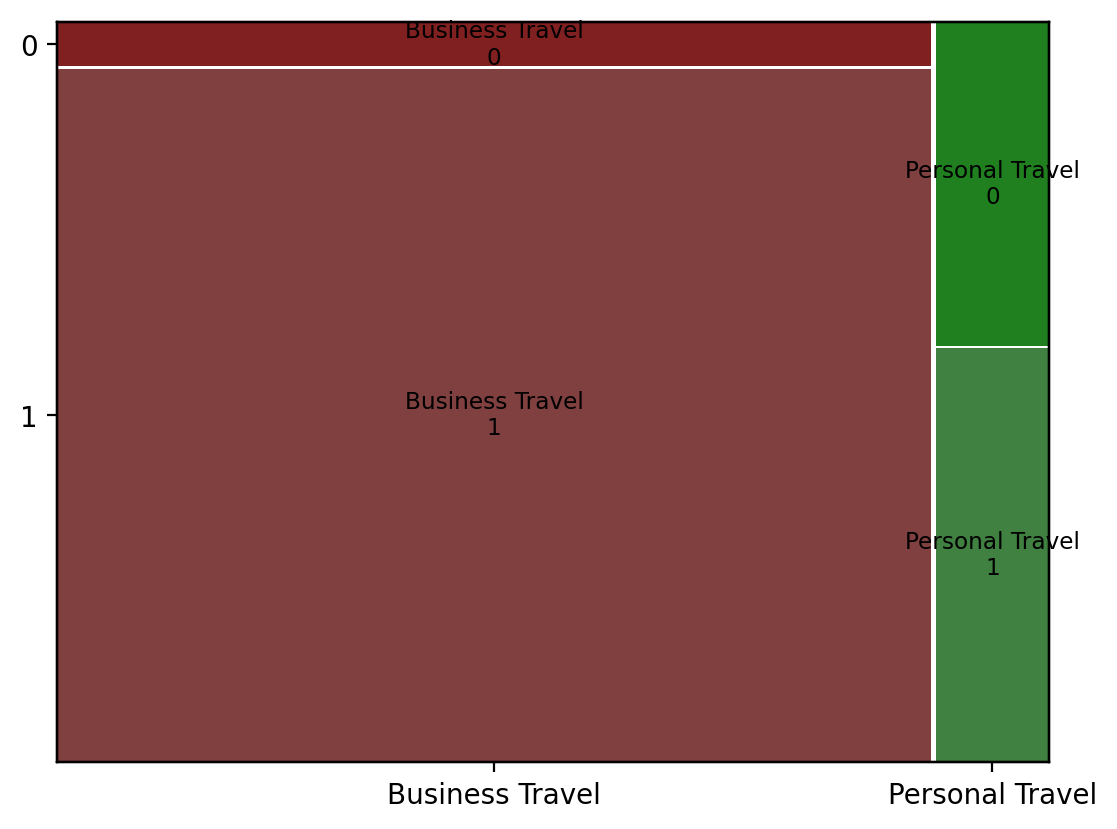

* 카이제곱통계량: 3056.2565232693446
* p-value: 0.0
* 기대빈도:
 [[ 1756.72191099 15304.27808901]
 [  228.27808901  1988.72191099]]


In [45]:
# 여행목적 -> 만족도
from statsmodels.graphics.mosaicplot import mosaic

table = pd.crosstab(data['Type of Travel'], data['Satisfaction'])
display(table)

mosaic(data, ['Type of Travel', 'Satisfaction'])
plt.show()

result = spst.chi2_contingency(table)
print('* 카이제곱통계량:', result[0])
print('* p-value:', result[1])
print('* 기대빈도:\n',result[3])
# 의견 : 여행 목적에 따른 만족도 차이가 매우 극명하며, 특히 개인 여행객(Personal)의 불만족율은 약 44%로 출장 고객 대비 7배 이상 높게 나타남
#        이는 개인 여행객이 주로 이용하는 노선 및 클래스의 서비스 품질이 이들의 기대치를 충족시키지 못하고 있음을 시사함..

Satisfaction,0,1
Gender,,
Female,991,8607
Male,994,8686


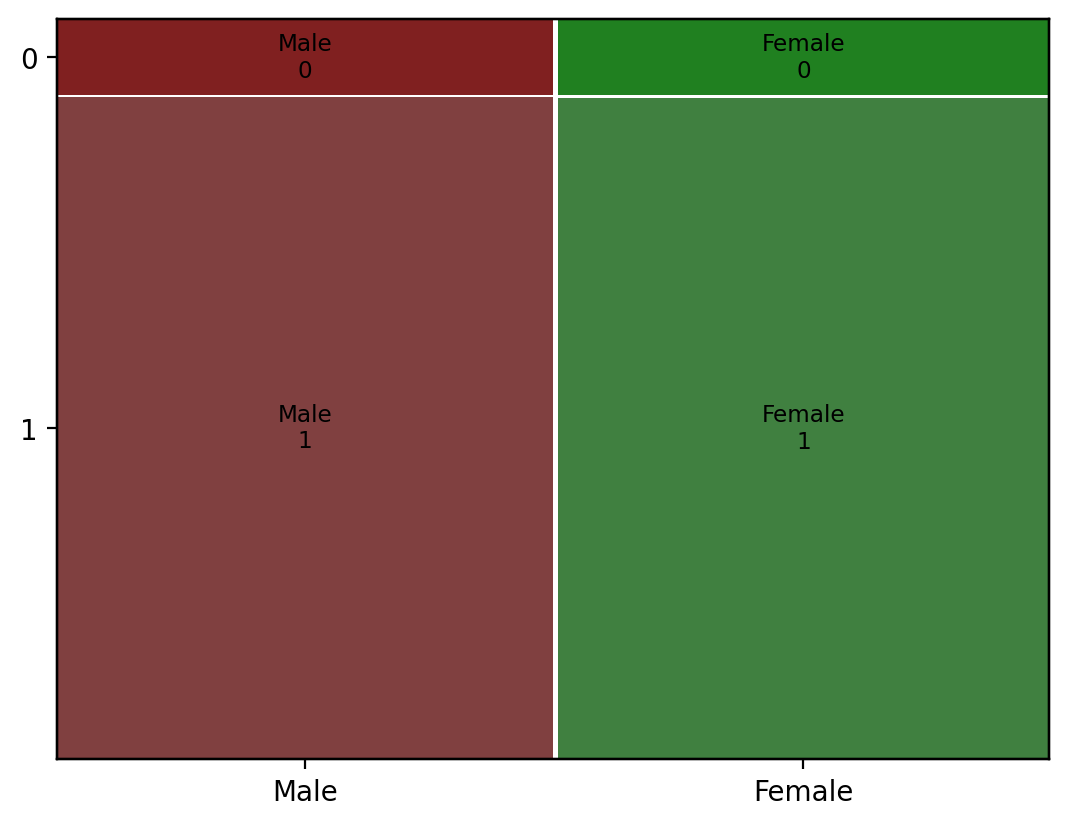

* 카이제곱통계량: 0.011087940559334602
* p-value: 0.9161383260229927
* 기대빈도:
 [[ 988.27834838 8609.72165162]
 [ 996.72165162 8683.27834838]]


In [47]:
# 성별 -> 만족도
from statsmodels.graphics.mosaicplot import mosaic

table = pd.crosstab(data['Gender'], data['Satisfaction'])
display(table)

mosaic(data, ['Gender', 'Satisfaction'])
plt.show()

result = spst.chi2_contingency(table)
print('* 카이제곱통계량:', result[0])
print('* p-value:', result[1])
print('* 기대빈도:\n',result[3])
# 의견 : 카이제곱 검정 결과, 성별에 따른 만족도 차이는 통계적으로 전혀 유의미하지 않으며, 남성과 여성 그룹 모두 유사한 만족도 분포를 보임.
#        이는 우리 항공사의 서비스 만족도가 성별이라는 인구통계학적 요인보다는 앞서 확인한 '여행 목적'이나 '좌석 등급' 같은 서비스 이용 환경에 의해 결정됨을 의미함.
#        따라서 향후 만족도 예측 모델 구축 시 성별 변수의 영향력은 매우 낮을 것으로 판단되며, 성별 맞춤형 전략보다는 기능적 서비스 개선에 집중하는 것이 효율적임.

## **4. 미션 3: 머신러닝 모델링 #1**

- Tree 기반 알고리즘을 사용해야 **변수 중요도**를 확인할 수 있습니다.
- **RandomForest** 알고리즘을 사용해 머신러닝 모델을 만들고 성능을 평가합니다.
- **변수 중요도**를 확인해 추가 분석 대상 변수를 선정합니다.

### (1) 전처리

- 최소한 문자열 데이터가 없어야 하고, 결측치도 없도록 전처리해야 합니다.
- 결측치는 이전 단계에서 처리한 상태입니다.
- 범주형 변수에 대해 **LabelEncoder**를 사용해 인코딩합니다.
- 변수 중요도를 확인하기 위함이므로 가변수화를 하지 않습니다.

In [ ]:
# 변수 확인
data.info()

In [ ]:
# 문자열 변수 리스트로 선언
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

# 라벨 인코딩
for col in cat_cols:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])

- info() 메서드로 변수 정보를 다시 확인합니다.
- **Dtype에 object 형식의 열이 있으면 이후 과정을 진행할 수 없습니다.**

In [ ]:
data.info()

- target 변수를 선정하고 x, y를 분리합니다.

In [ ]:
target = 'Satisfaction'

x = data.drop(target, axis=1)
y = data[target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=42)

### (2) 모델링

- 머신러닝 모델링을 수행합니다.
- 검증 데이터로 예측하고 성능을 평가해 봅니다.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(max_depth=15)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [ ]:
# 모듈 불러오기
from sklearn.metrics import classification_report

# 성능 평가
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83       596
           1       0.98      0.99      0.98      5188

    accuracy                           0.97      5784
   macro avg       0.93      0.89      0.91      5784
weighted avg       0.97      0.97      0.97      5784



In [ ]:
# 모듈 불러오기
from sklearn.metrics import confusion_matrix
# 성능 평가
confusion_matrix(y_test, y_pred)

array([[ 466,  130],
       [  60, 5128]])

### (3) 변수 중요도 확인

- 변수 중요도를 시각화해 확인합니다.

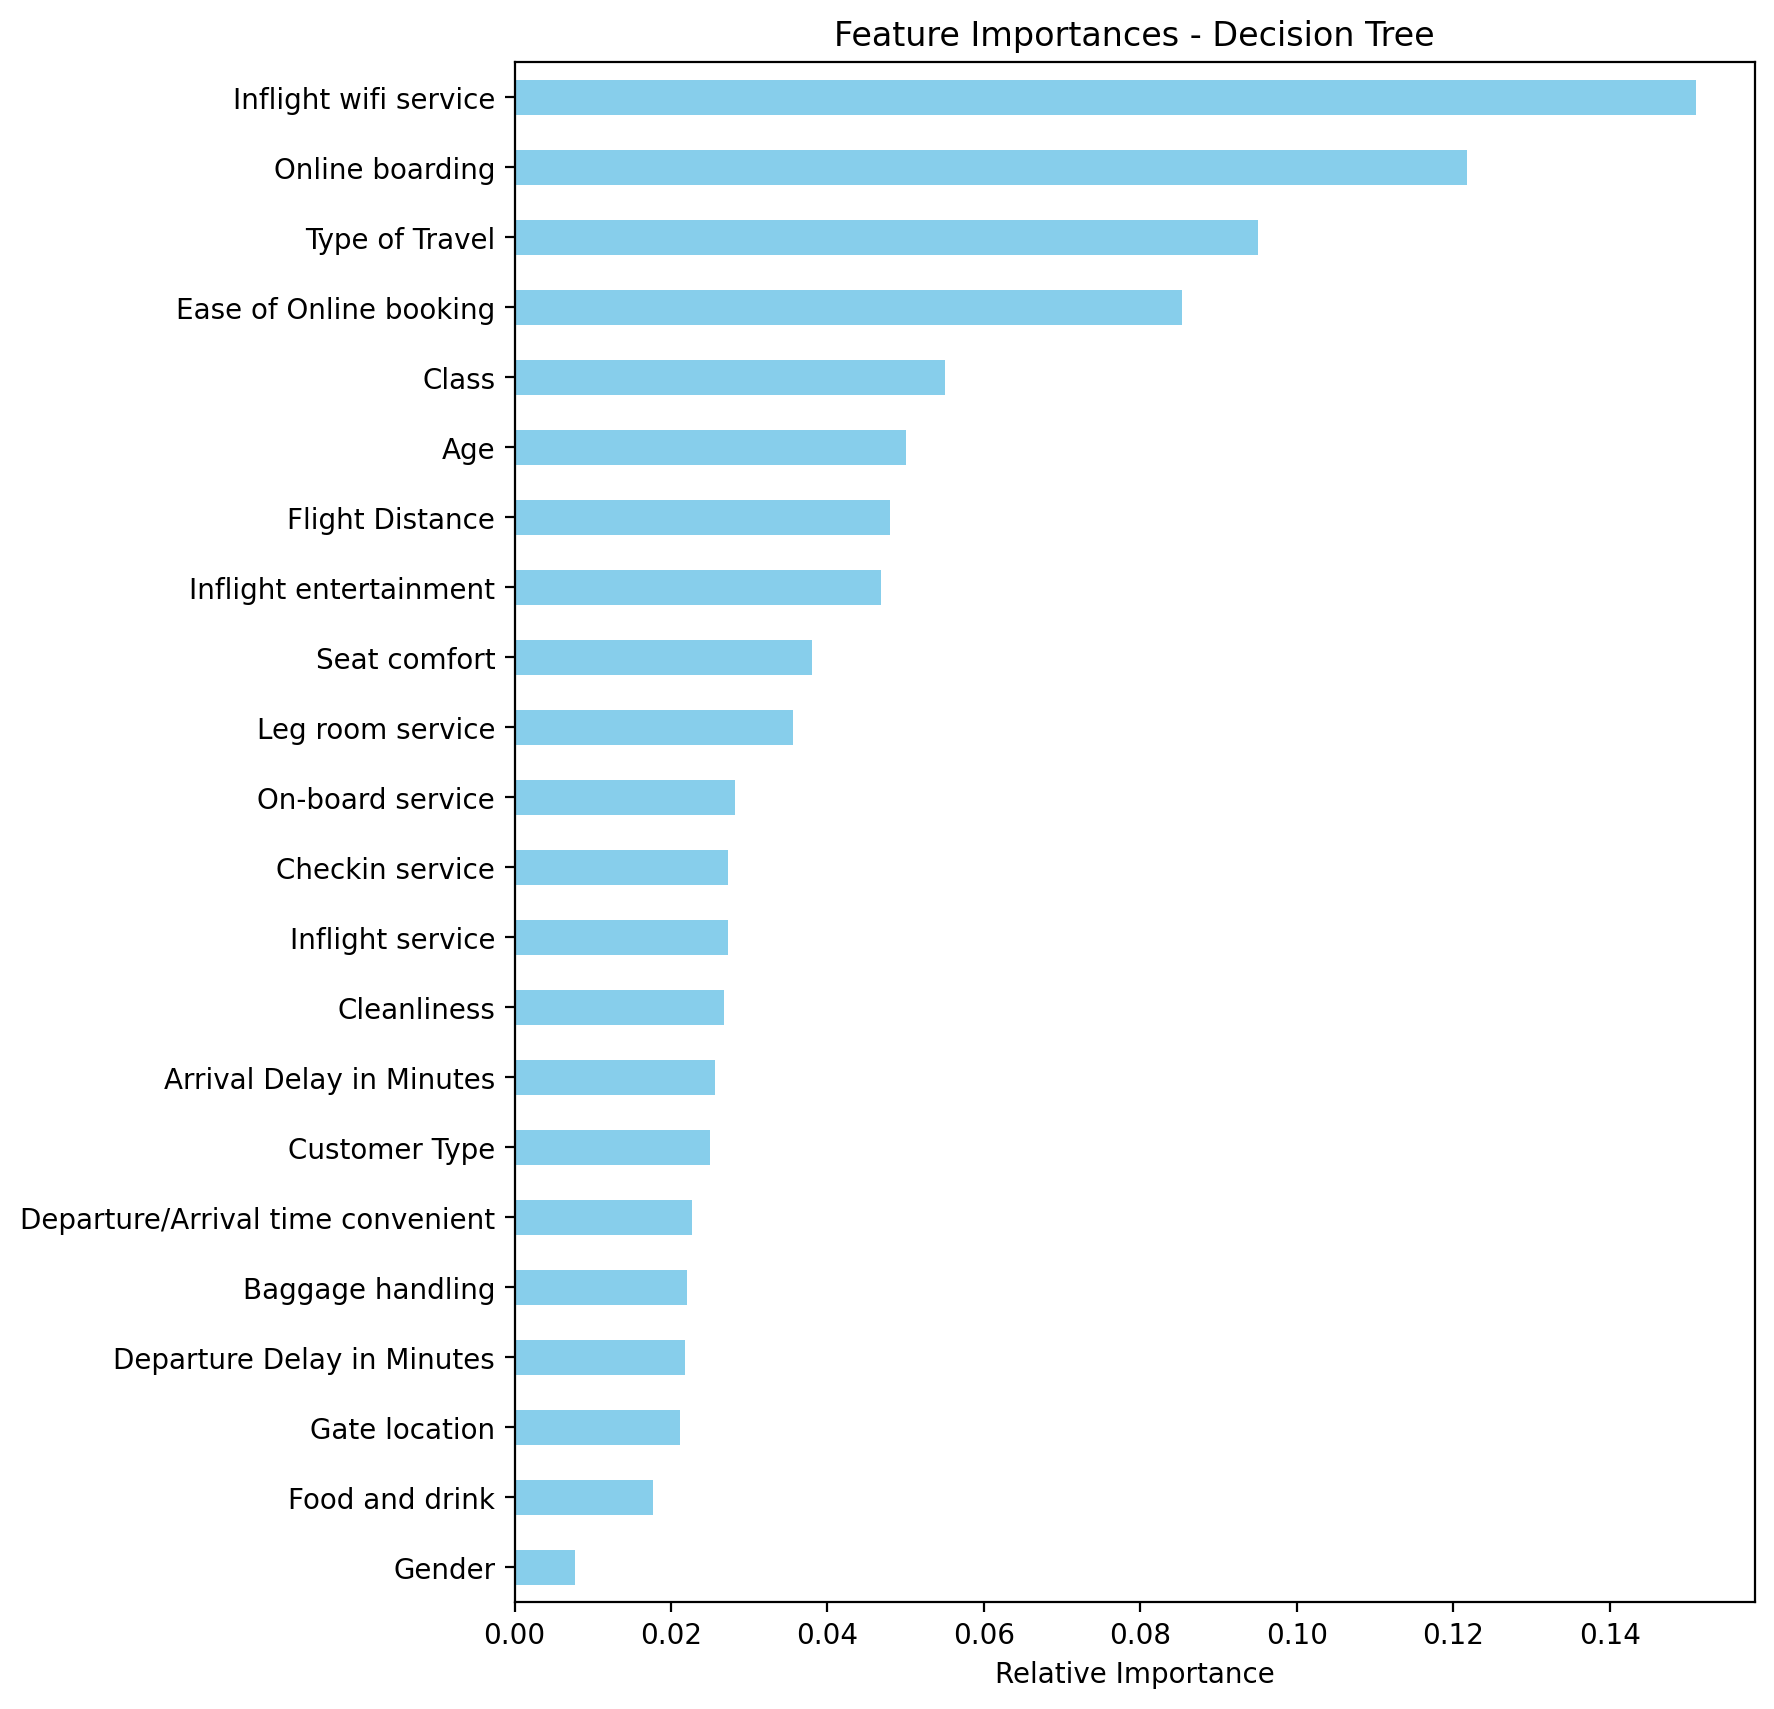

In [ ]:
# 1. 변수 중요도 추출 및 정렬 (가독성을 위해)
# model.feature_importances_는 각 변수의 중요도 수치를 배열로 반환합니다.
feat_importances = pd.Series(model.feature_importances_, index=x.columns)
feat_importances = feat_importances.sort_values(ascending=True) # 낮은 순 정렬 (barh에서 위가 높게 보임)

# 2. 시각화
plt.figure(figsize=(8, 10))
feat_importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importances - Decision Tree')
plt.xlabel('Relative Importance')
plt.show()

### (4) 결과 정리

- 가장 중요하다고 확인된 변수 5개는 무엇인가요?


In [ ]:
# 내림차순 정렬 후 상위 5개 추출
ftr_top5 = feat_importances.sort_values(ascending=False).head(5)

print(ftr_top5)

Inflight wifi service     0.150975
Online boarding           0.121748
Type of Travel            0.095101
Ease of Online booking    0.085330
Class                     0.054965
dtype: float64


- 가장 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [ ]:
# 오름차순 정렬 후 상위 5개 추출
ftr_top5 = feat_importances.sort_values().head(5)

print(ftr_top5)

Gender                        0.007681
Food and drink                0.017716
Gate location                 0.021208
Departure Delay in Minutes    0.021787
Baggage handling              0.022006
dtype: float64


## **5. 미션 4: 머신러닝 모델링 #2**

- 35세를 기준으로 데이터를 분리해 각각에 대한 모델을 만들어봅니다.

### (1) 데이터 분리

- 더 세분화할 수 있지만, 35세를 기준으로 두 개의 데이터프레임을 만듭니다.
    - **data01**: Age <= 35
    - **data02**: Age > 35

In [ ]:
# 데이터 분리
data01 = data.loc[data['Age'] <= 35]
data02 = data.loc[data['Age'] > 35]

### (2) 35세 이하 모델링

- **data01** 데이터프레임을 대상으로 모델링을 수행합니다.
- 우선 target 변수를 선정하고 x, y를 분리합니다.

In [ ]:
target = 'Satisfaction'

x = data01.drop(target, axis=1)
y = data01[target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=42)

- 모델링을 수행합니다.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [ ]:
# 모듈 불러오기
from sklearn.metrics import classification_report

# 성능 평가
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.77      0.83       275
           1       0.96      0.98      0.97      1474

    accuracy                           0.95      1749
   macro avg       0.93      0.88      0.90      1749
weighted avg       0.95      0.95      0.95      1749



In [ ]:
# 모듈 불러오기
from sklearn.metrics import confusion_matrix
# 성능 평가
confusion_matrix(y_test, y_pred)

array([[ 212,   63],
       [  25, 1449]])

- 변수 중요도를 확인합니다.

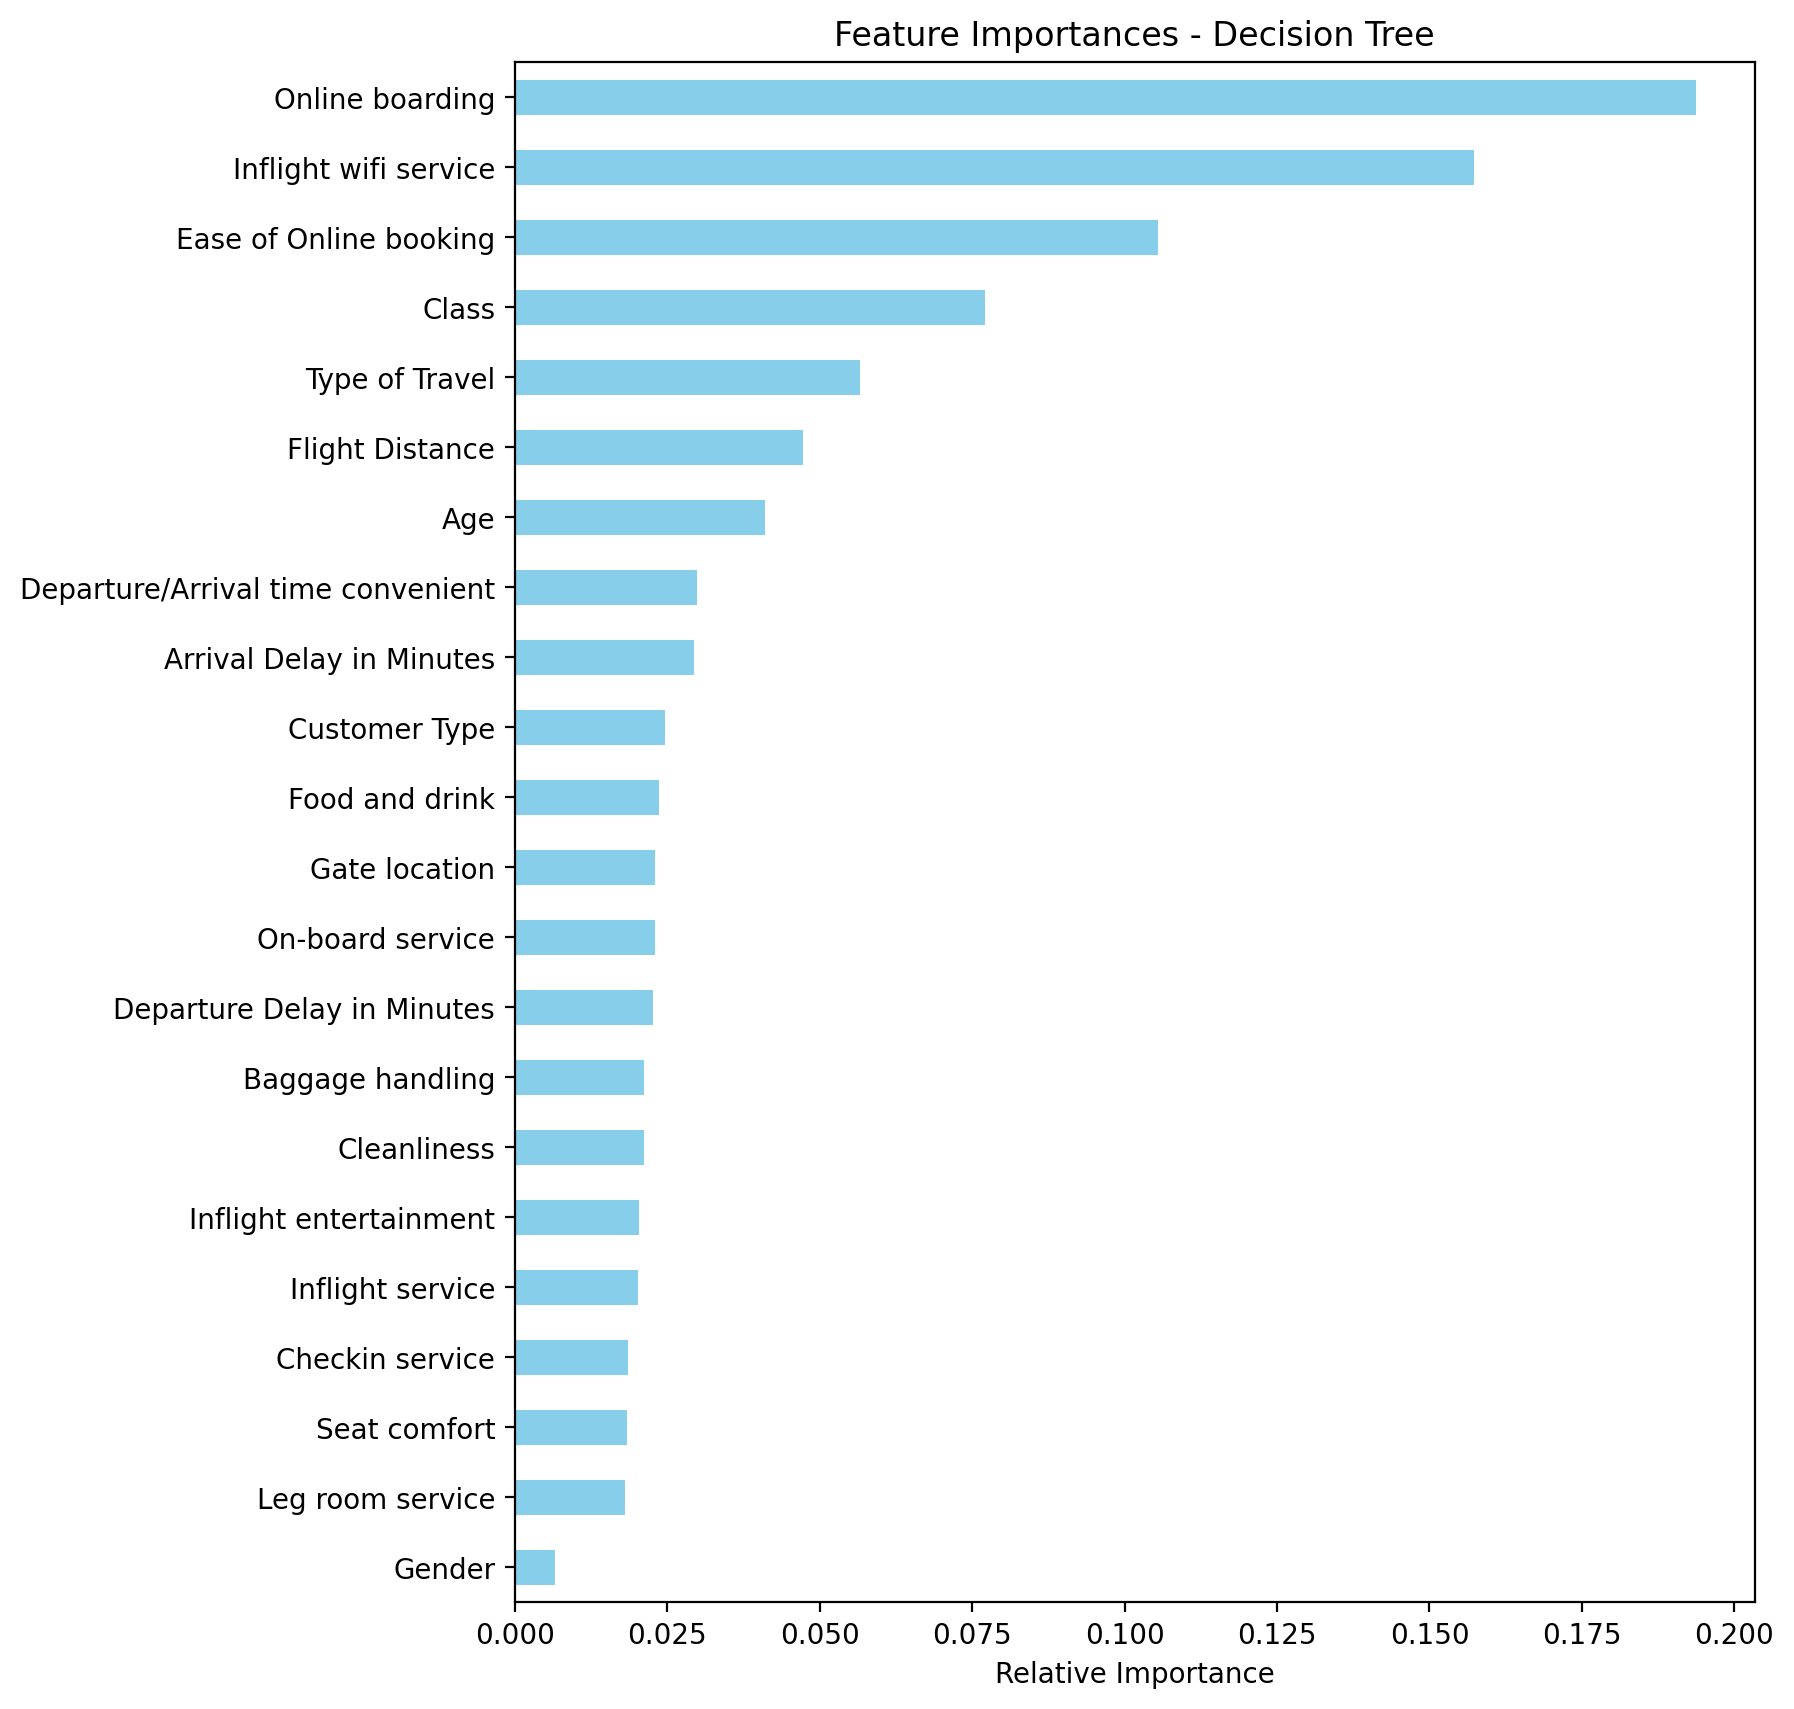

In [ ]:
# 1. 변수 중요도 추출 및 정렬 (가독성을 위해)
# model.feature_importances_는 각 변수의 중요도 수치를 배열로 반환합니다.
feat_importances = pd.Series(model.feature_importances_, index=x.columns)
feat_importances = feat_importances.sort_values(ascending=True) # 낮은 순 정렬 (barh에서 위가 높게 보임)

# 2. 시각화
plt.figure(figsize=(8, 10))
feat_importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importances - Decision Tree')
plt.xlabel('Relative Importance')
plt.show()

- 중요하다고 확인된 변수 5개는 무엇인가요?


In [ ]:
# 내림차순 정렬 후 상위 5개 추출
ftr_top5 = feat_importances.sort_values(ascending=False).head(5)

print(ftr_top5)

Online boarding           0.193621
Inflight wifi service     0.157324
Ease of Online booking    0.105482
Class                     0.077078
Type of Travel            0.056576
dtype: float64


- 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [ ]:
# 오차순 정렬 후 상위 5개 추출
ftr_top5 = feat_importances.sort_values().head(5)

print(ftr_top5)

Gender              0.006680
Leg room service    0.018102
Seat comfort        0.018491
Checkin service     0.018589
Inflight service    0.020251
dtype: float64


### (3) 35세 초과 모델링

- **data02** 데이터프레임을 대상으로 모델링을 수행합니다.
- 우선 target 변수를 선정하고 x, y를 분리합니다.

In [ ]:
target = 'Satisfaction'

x = data02.drop(target, axis=1)
y = data02[target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=42)

- 모델링을 수행합니다.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [ ]:
# 모듈 불러오기
from sklearn.metrics import classification_report

# 성능 평가
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.76      0.82       321
           1       0.98      0.99      0.99      3714

    accuracy                           0.97      4035
   macro avg       0.94      0.88      0.91      4035
weighted avg       0.97      0.97      0.97      4035



- 변수 중요도를 확인합니다.

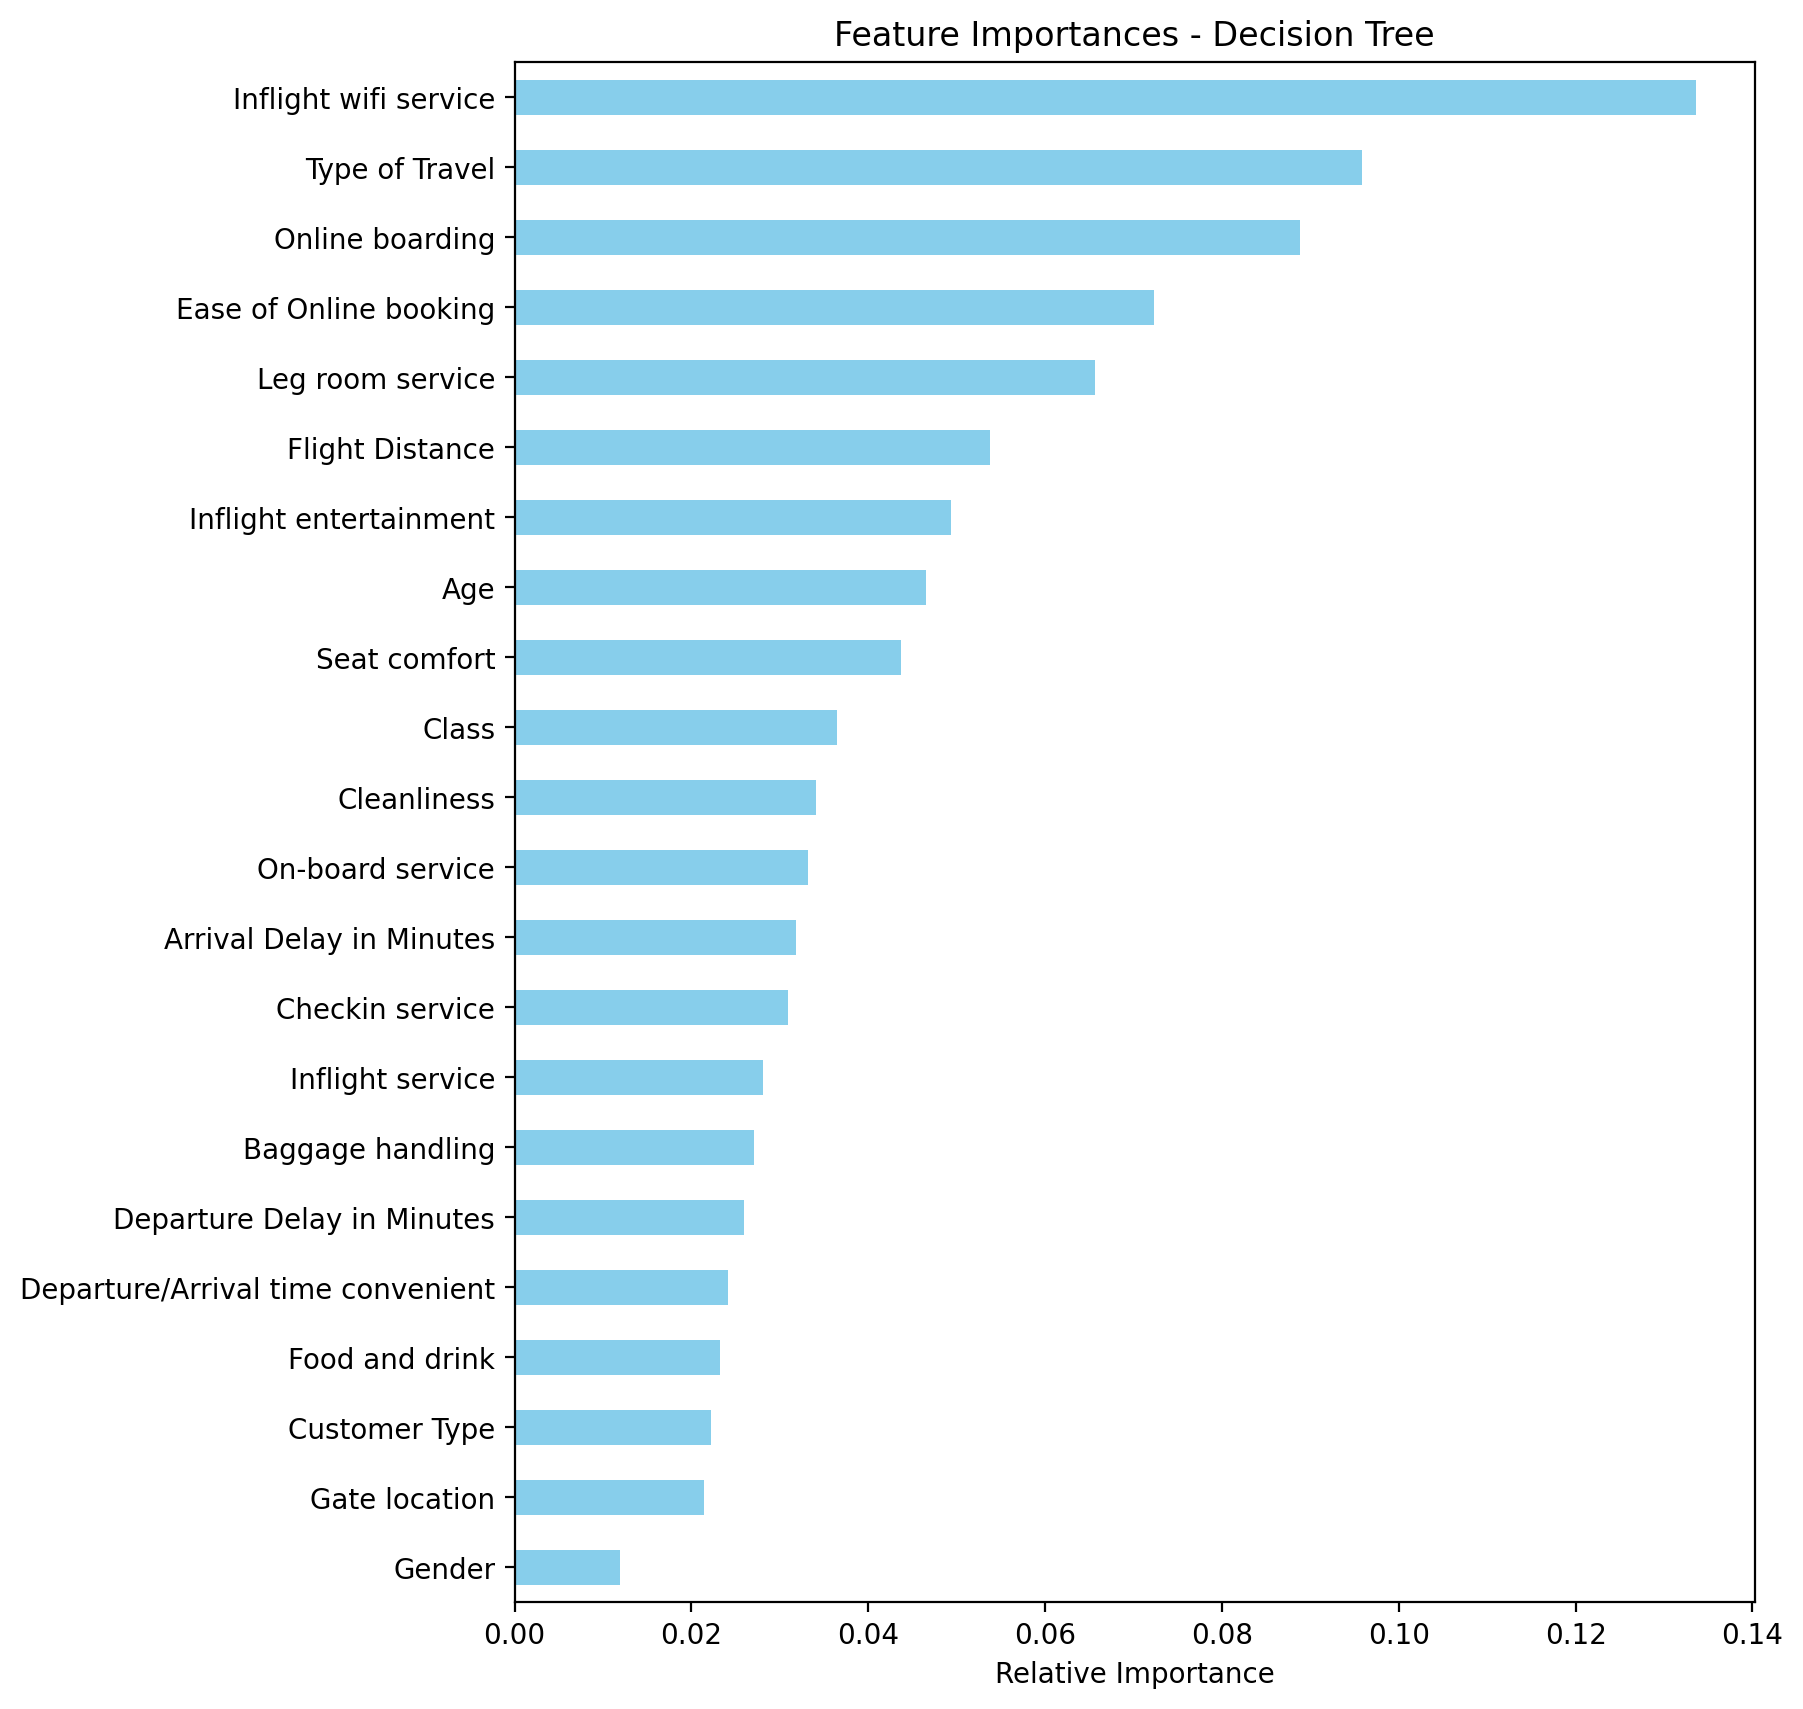

In [ ]:
# 1. 변수 중요도 추출 및 정렬 (가독성을 위해)
# model.feature_importances_는 각 변수의 중요도 수치를 배열로 반환합니다.
feat_importances = pd.Series(model.feature_importances_, index=x.columns)
feat_importances = feat_importances.sort_values(ascending=True) # 낮은 순 정렬 (barh에서 위가 높게 보임)

# 2. 시각화
plt.figure(figsize=(8, 10))
feat_importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importances - Decision Tree')
plt.xlabel('Relative Importance')
plt.show()

- 가장 중요하다고 확인된 변수 5개는 무엇인가요?


In [ ]:
# 내림차순 정렬 후 상위 5개 추출
ftr_top5 = feat_importances.sort_values(ascending=False).head(5)

print(ftr_top5)

Inflight wifi service     0.133563
Type of Travel            0.095827
Online boarding           0.088863
Ease of Online booking    0.072290
Leg room service          0.065603
dtype: float64


- 가장 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [ ]:
# 오름차순 정렬 후 상위 5개 추출
ftr_top5 = feat_importances.sort_values().head(5)

print(ftr_top5)

Gender                               0.011873
Gate location                        0.021449
Customer Type                        0.022225
Food and drink                       0.023284
Departure/Arrival time convenient    0.024131
dtype: float64


### (4) 의견 정리

- 위 모델링 과정과 변수 중요도 확인 과정 결과에 대한 의견을 정리합니다.

In [ ]:
# 세 그래프 모두에서 Inflight wifi service와 Online boarding, 온라인 예약 편의성과 여행목적이 상위권을 차지하고 있습니다
# 35세 이하 집단에서는 좌석등급이 주요 변수로 나타났습니다.
# 35세 초과 집단에서는 전체 데이터에서는 보이지 않던 Leg room service(다리 공간 만족도)가 올라온 것을 확인할 수 있었습니다.

### (2) 데이터 분리 - 개인적으로 추가로 더 분석한 결과

- 더 세분화할 수 있지만, 여행목적을 기준으로 두 개의 데이터프레임을 만듭니다.
    - **data03**: 비지니스 여행
    - **data04**: 개인 여행

In [ ]:
data03 = data.loc[data['Type of Travel'] == 0]
data04 = data.loc[data['Type of Travel'] == 1]

### (2) 비지니스 여행 모델링

- **data03** 데이터프레임을 대상으로 모델링을 수행합니다.
- 우선 target 변수를 선정하고 x, y를 분리합니다.

In [ ]:
target = 'Satisfaction'

x = data03.drop(target, axis=1)
y = data03[target]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [ ]:
# 모듈 불러오기
from sklearn.metrics import classification_report

# 성능 평가
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.69      0.76       304
           1       0.98      0.99      0.99      4815

    accuracy                           0.97      5119
   macro avg       0.92      0.84      0.88      5119
weighted avg       0.97      0.97      0.97      5119



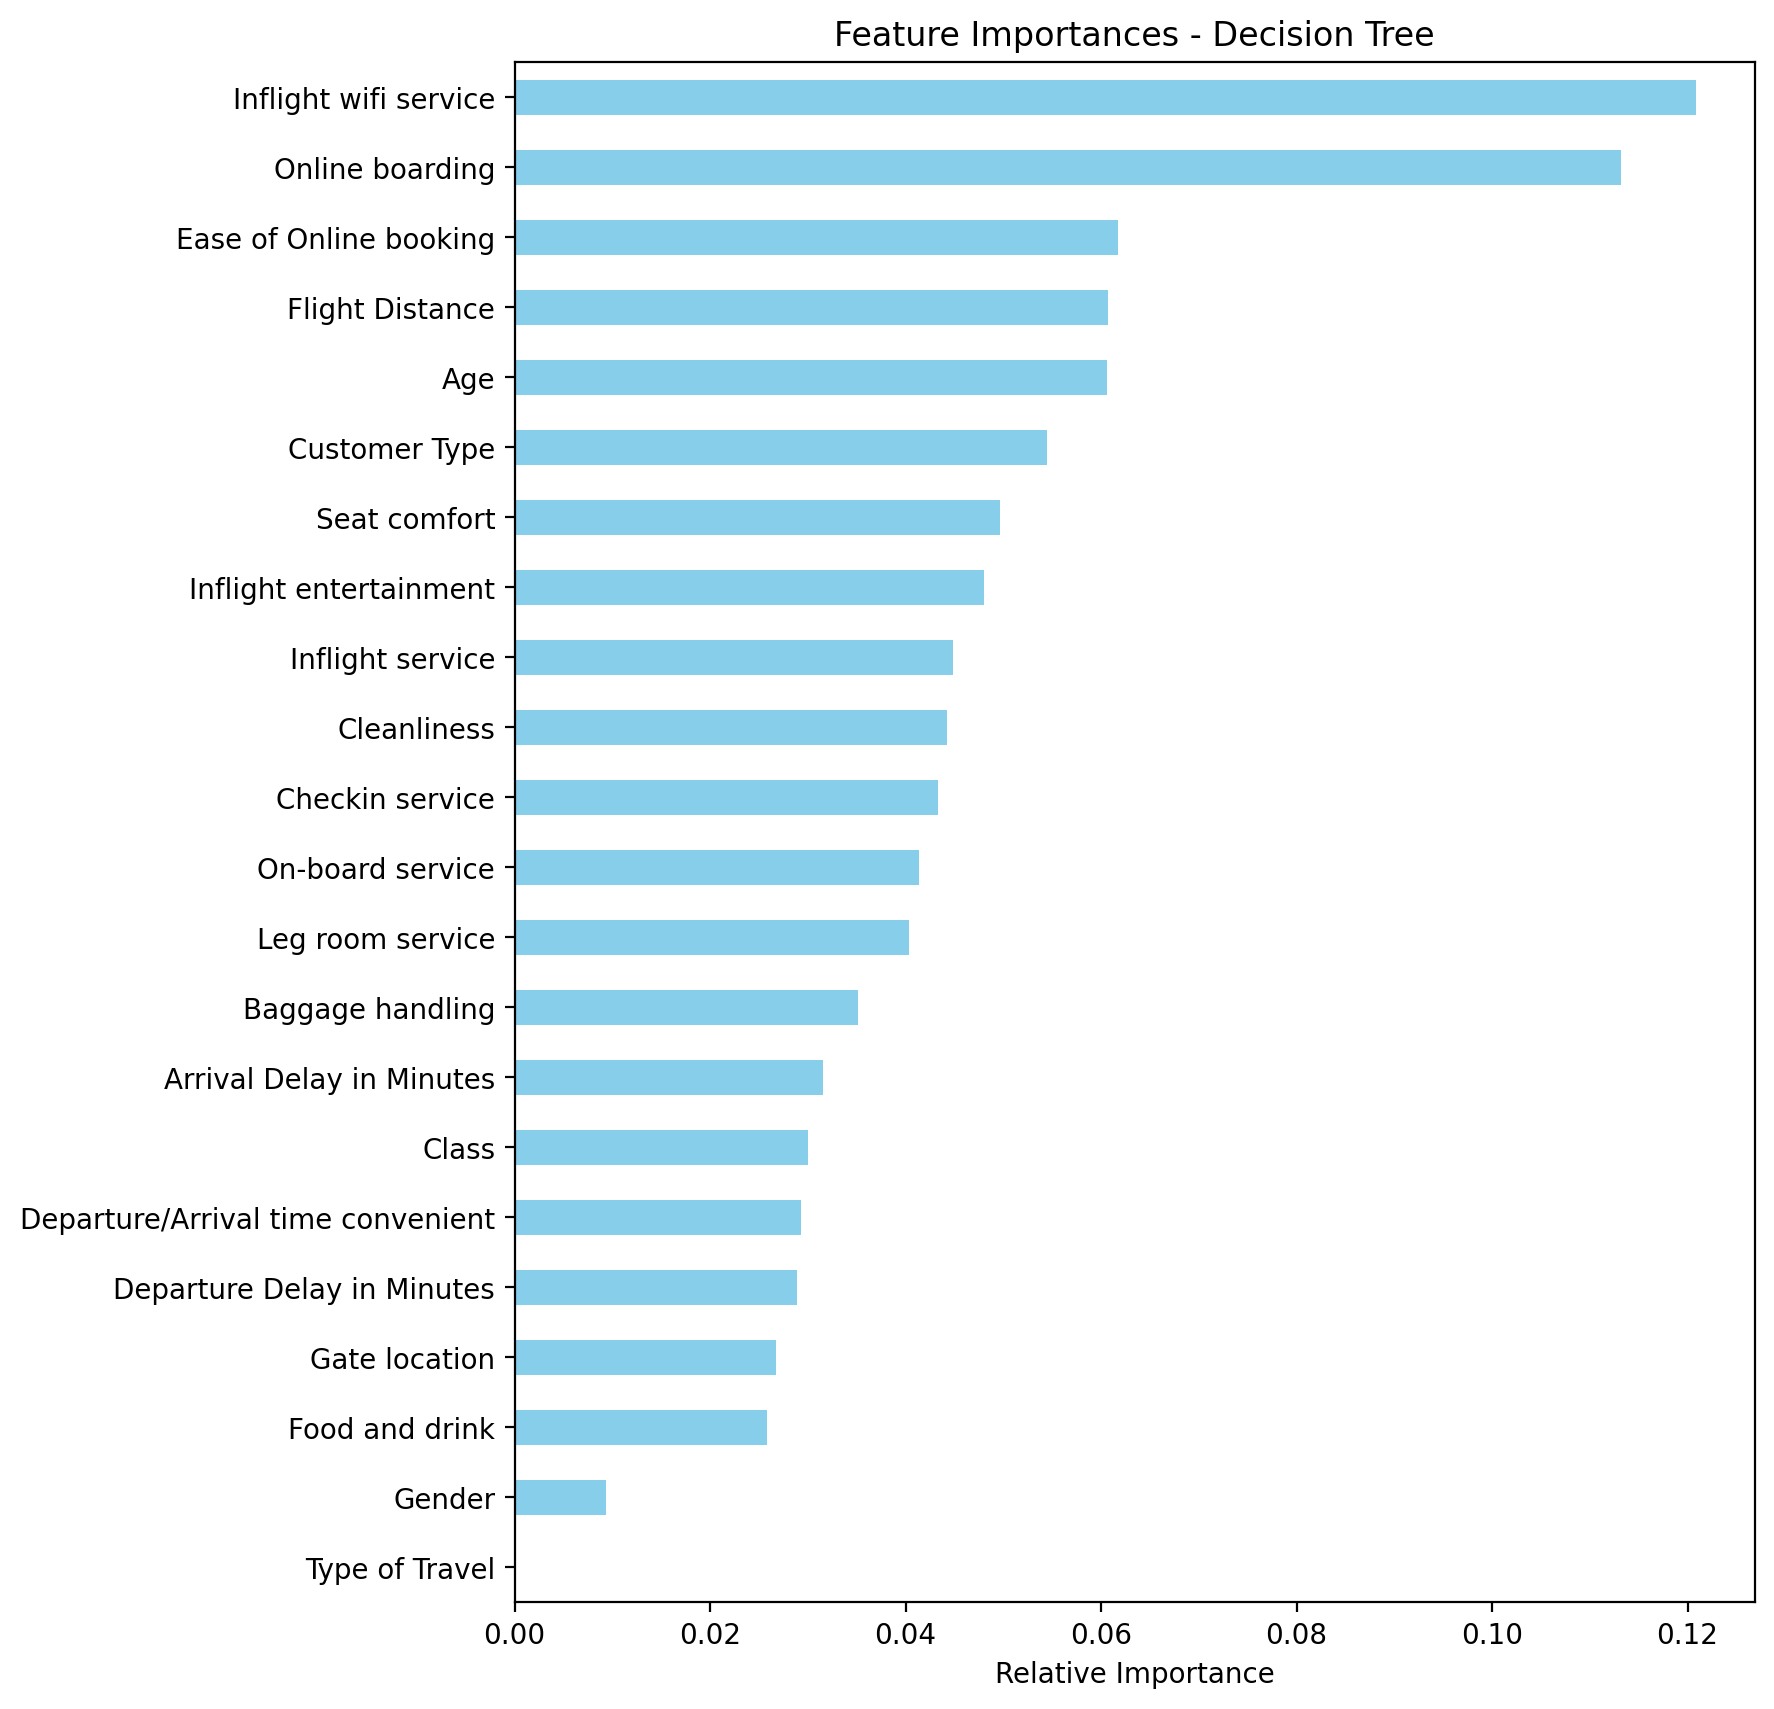

In [ ]:
# 1. 변수 중요도 추출 및 정렬 (가독성을 위해)
# model.feature_importances_는 각 변수의 중요도 수치를 배열로 반환합니다.
feat_importances = pd.Series(model.feature_importances_, index=x.columns)
feat_importances = feat_importances.sort_values(ascending=True) # 낮은 순 정렬 (barh에서 위가 높게 보임)

# 2. 시각화
plt.figure(figsize=(8, 10))
feat_importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importances - Decision Tree')
plt.xlabel('Relative Importance')
plt.show()

In [ ]:
# 내림차순 정렬 후 상위 5개 추출
ftr_top5 = feat_importances.sort_values(ascending=False).head(5)

print(ftr_top5)

Inflight wifi service     0.120819
Online boarding           0.113172
Ease of Online booking    0.061694
Flight Distance           0.060727
Age                       0.060647
dtype: float64


In [ ]:
# 오름차순 정렬 후 상위 5개 추출
ftr_top5 = feat_importances.sort_values().head(5)

print(ftr_top5)

Type of Travel                0.000000
Gender                        0.009347
Food and drink                0.025795
Gate location                 0.026696
Departure Delay in Minutes    0.028944
dtype: float64


### (2) 개인 여행 모델링

- **data04** 데이터프레임을 대상으로 모델링을 수행합니다.
- 우선 target 변수를 선정하고 x, y를 분리합니다.

In [ ]:
target = 'Satisfaction'

x = data04.drop(target, axis=1)
y = data04[target]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [ ]:
# 모듈 불러오기
from sklearn.metrics import classification_report

# 성능 평가
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90       292
           1       0.90      0.97      0.93       374

    accuracy                           0.92       666
   macro avg       0.93      0.91      0.92       666
weighted avg       0.92      0.92      0.92       666



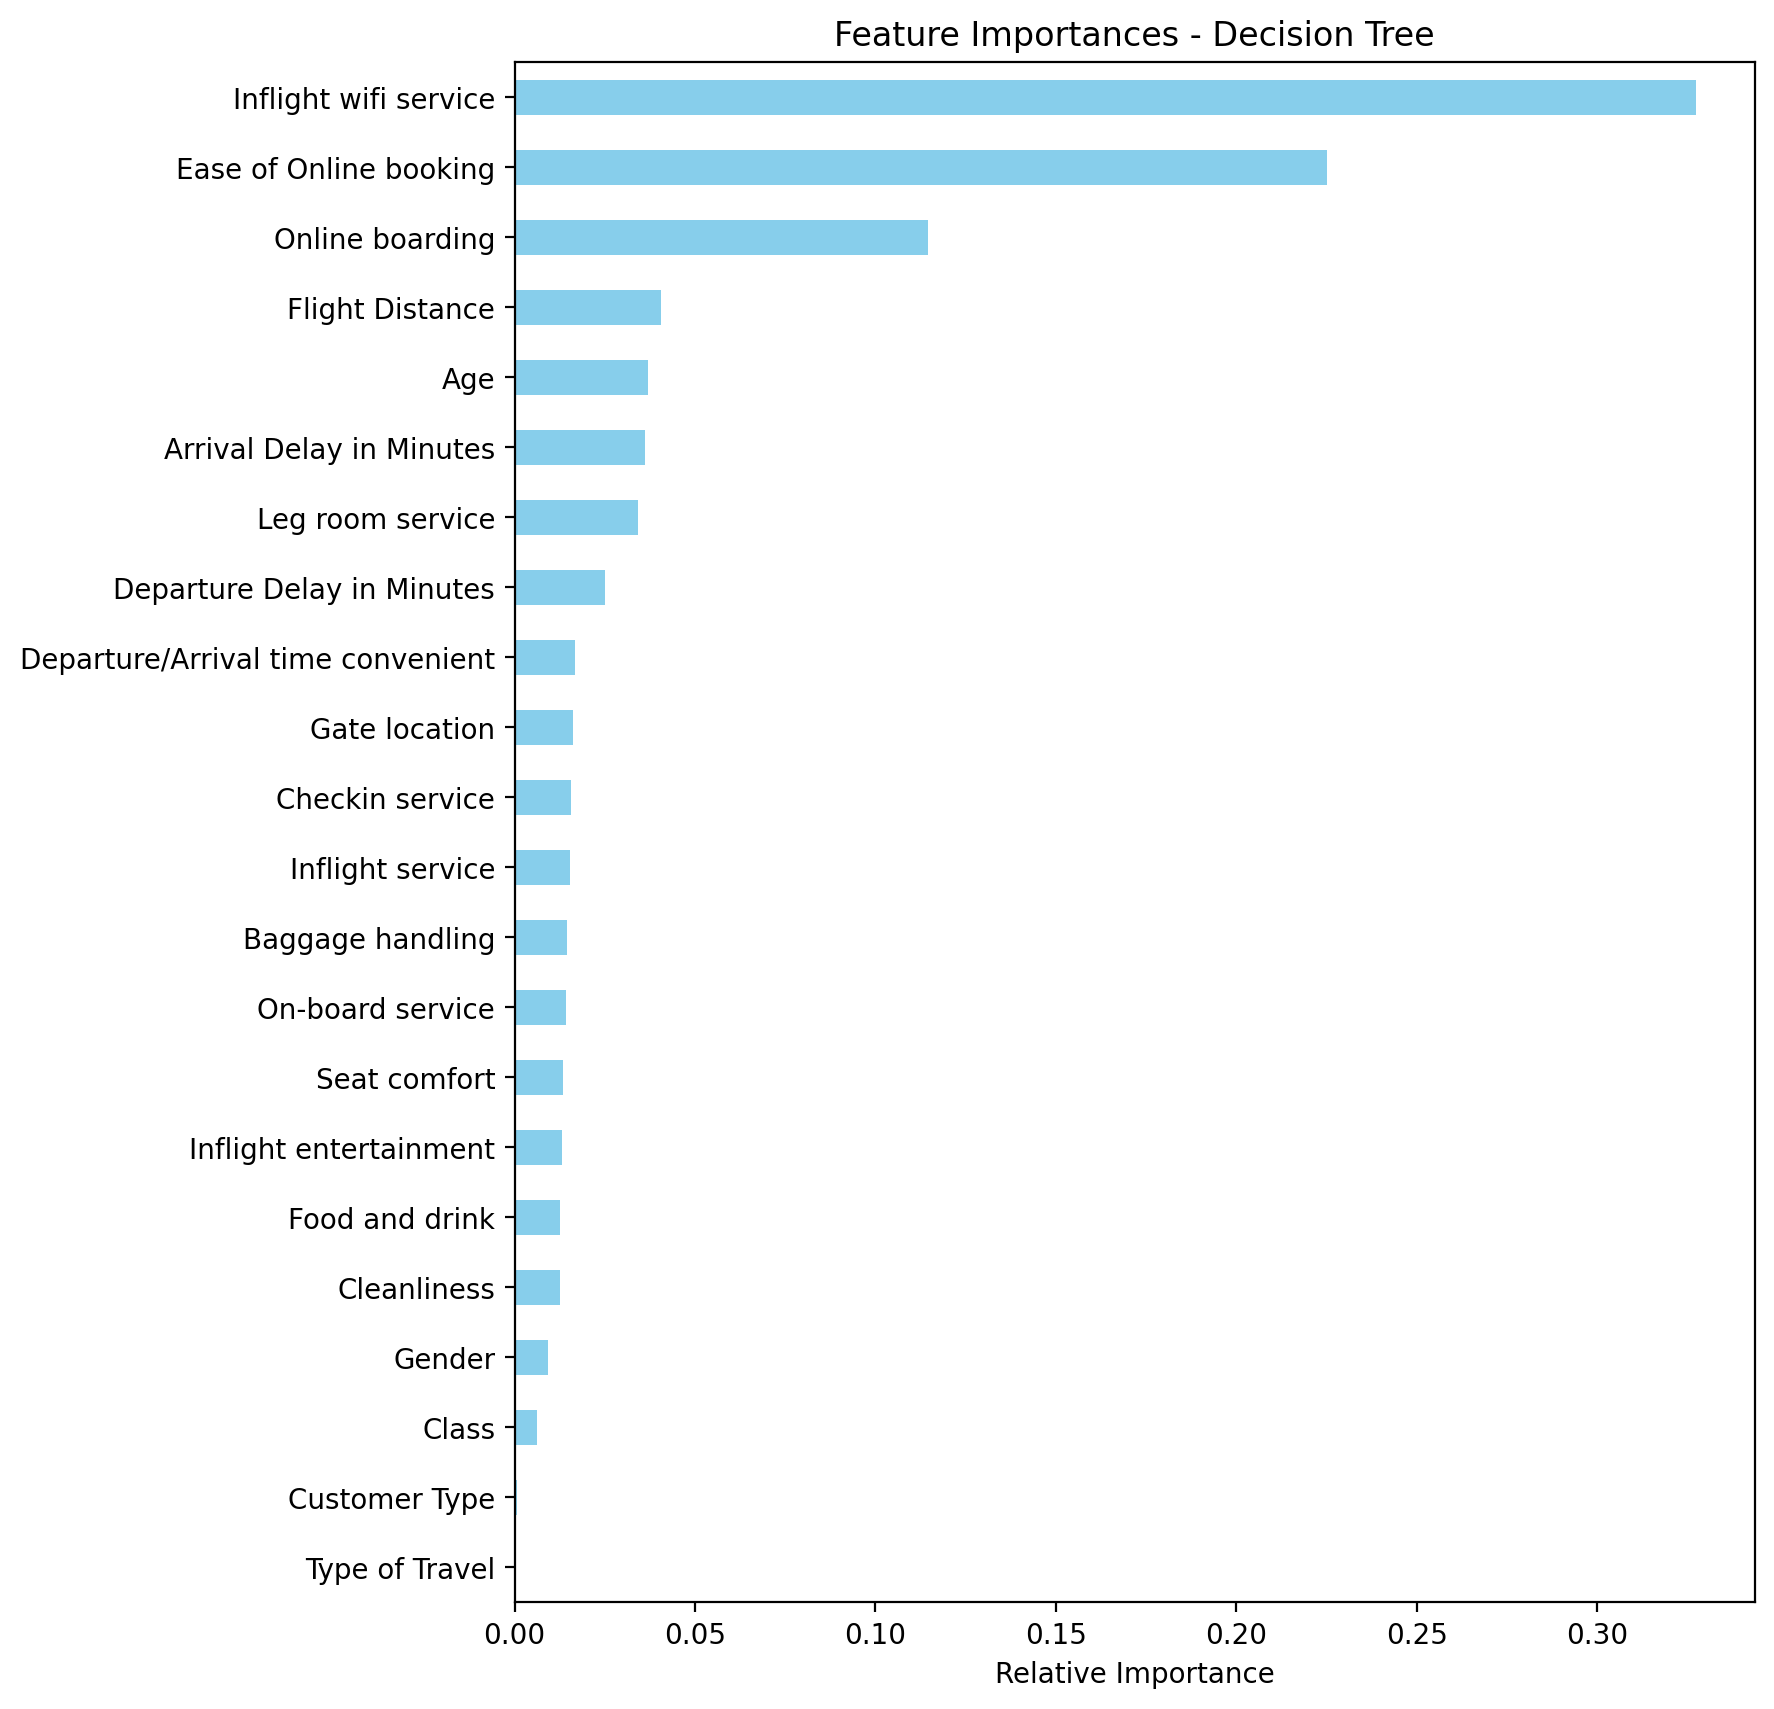

In [ ]:
# 1. 변수 중요도 추출 및 정렬 (가독성을 위해)
# model.feature_importances_는 각 변수의 중요도 수치를 배열로 반환합니다.
feat_importances = pd.Series(model.feature_importances_, index=x.columns)
feat_importances = feat_importances.sort_values(ascending=True) # 낮은 순 정렬 (barh에서 위가 높게 보임)

# 2. 시각화
plt.figure(figsize=(8, 10))
feat_importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importances - Decision Tree')
plt.xlabel('Relative Importance')
plt.show()

In [ ]:
# 내림차순 정렬 후 상위 5개 추출
ftr_top5 = feat_importances.sort_values(ascending=False).head(5)

print(ftr_top5)

Inflight wifi service     0.327266
Ease of Online booking    0.225103
Online boarding           0.114556
Flight Distance           0.040471
Age                       0.036893
dtype: float64


In [ ]:
# 오름차순 정렬 후 상위 5개 추출
ftr_top5 = feat_importances.sort_values().head(5)

print(ftr_top5)

Type of Travel    0.000000
Customer Type     0.000769
Class             0.006220
Gender            0.009318
Cleanliness       0.012541
dtype: float64


In [ ]:
# 종합적인 의견 : Ease of Online booking(온라인 예약 편의성), Online boarding(온라인 탑승수속), Inflight wifi service(기내 와이파이 서비스)
#                 가 공통적으로 상위권에 포함되면서 이 3가지 서비스들을 더욱 더 신경쓰면은 좋을 것 같다.

#                 연령대가 높아질수록 장시간 비행 시 신체적 피로도를 결정짓는 공간의 넓이가 만족도에 큰 영향을 미친다고 보여지는데
#                 비행거리가 장거리라면 더 넓은 좌석을 추천하는 마케팅이 효과적일 것 같다.

#                 35세 미만 고객군은 좌석 등급(Class)에 따른 서비스 차별화를 가장 즉각적으로 만족도에 반영하는 집단이므로,
#                 이들을 타겟으로 한 '좌석 업그레이드 프로모션' 등이 만족도 제고에 매우 효과적일 수 있습니다

#                 비지니스 여행객들은 전체적인 서비스들을 본다는 느낌이 강하게 들고 한정된 자원을 특정 서비스에 집중하기보다,
#                 모든 접점에서의 서비스 품질을 상향 평준화하여 안정적인 경험을 제공하는 것이 비즈니스 고객의 만족도를 확보하는 핵심 전략이 될 것입니다."

## **6. 미션 5: 데이터 분석**

- 위에서 확인된 변수 중요도를 기준으로 분석할 변수를 5개 선정하고 분석을 수행합니다.
- **data** 데이터프레임을 대상으로 분석합니다.
- Satisfaction 변수와의 **이변량 분석**에 중점을 두고 수행합니다.
- 각 분석 결과에 대한 의견을 주석으로 정리합니다.

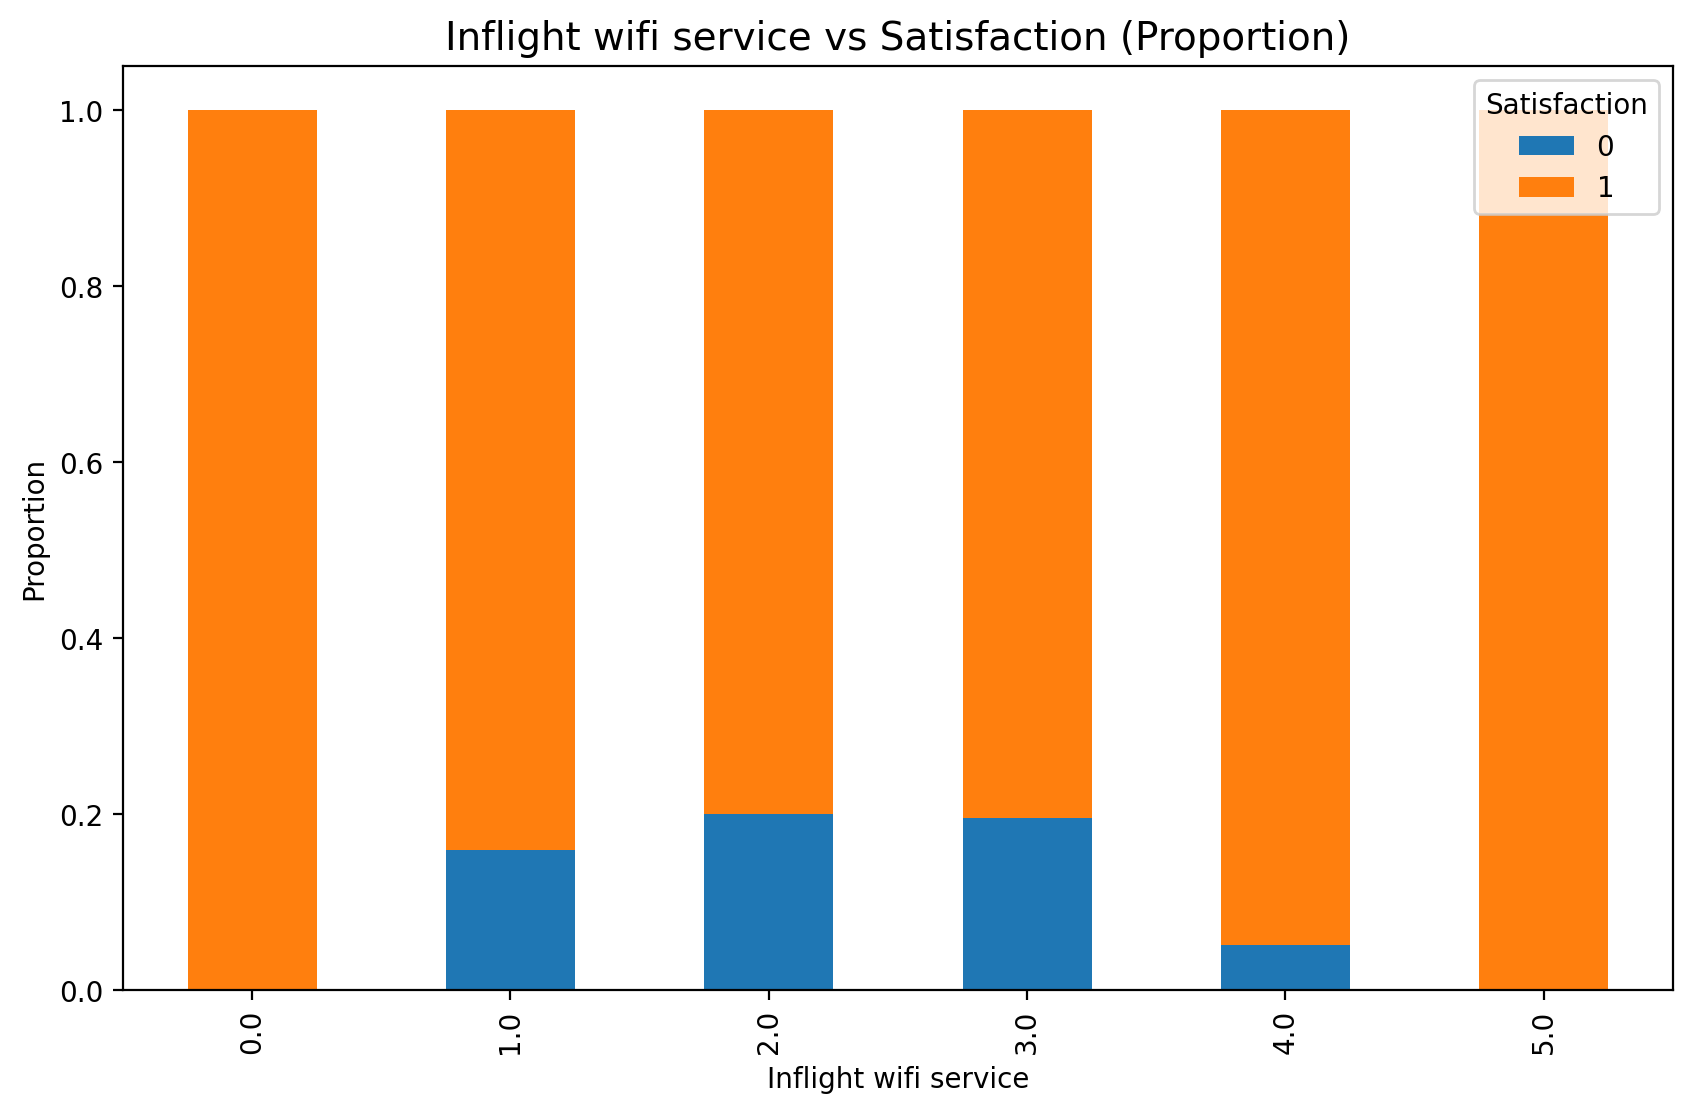

[Inflight wifi service 분석 결과]
P-value: 0.0000
결론: Inflight wifi service 등급에 따라 만족도 비율이 통계적으로 유의미하게 차이남.
------------------------------


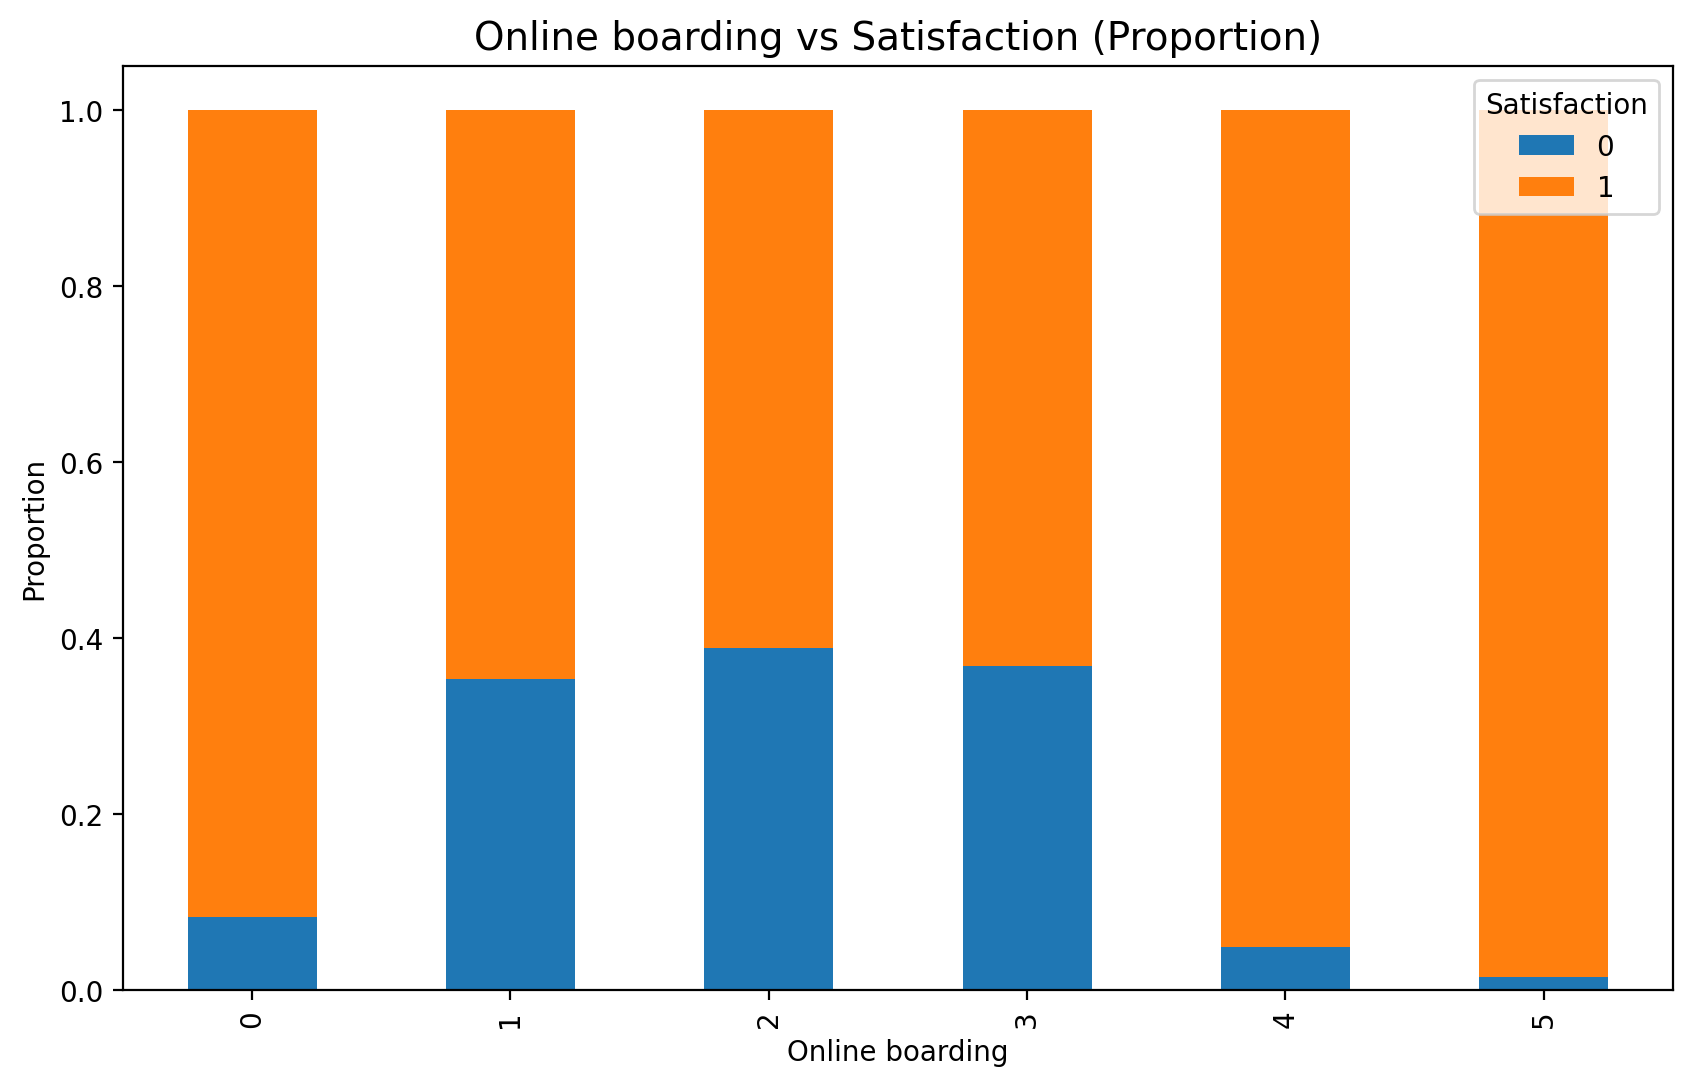

[Online boarding 분석 결과]
P-value: 0.0000
결론: Online boarding 등급에 따라 만족도 비율이 통계적으로 유의미하게 차이남.
------------------------------


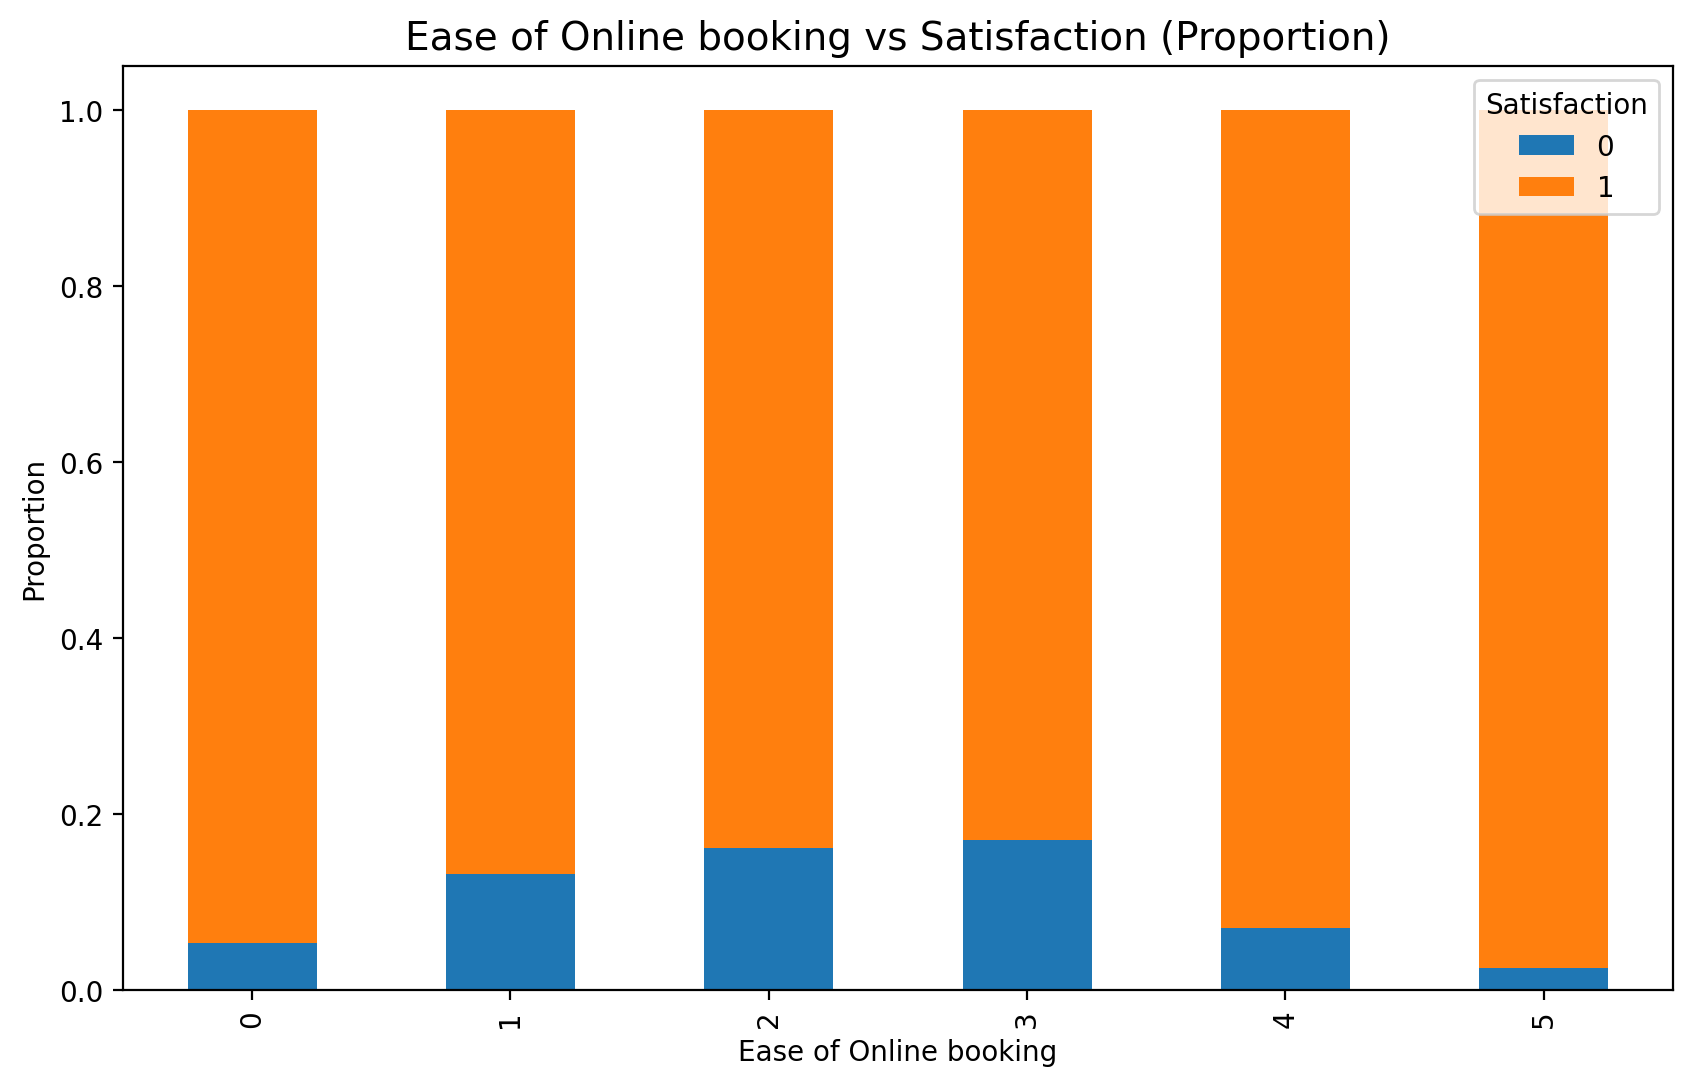

[Ease of Online booking 분석 결과]
P-value: 0.0000
결론: Ease of Online booking 등급에 따라 만족도 비율이 통계적으로 유의미하게 차이남.
------------------------------


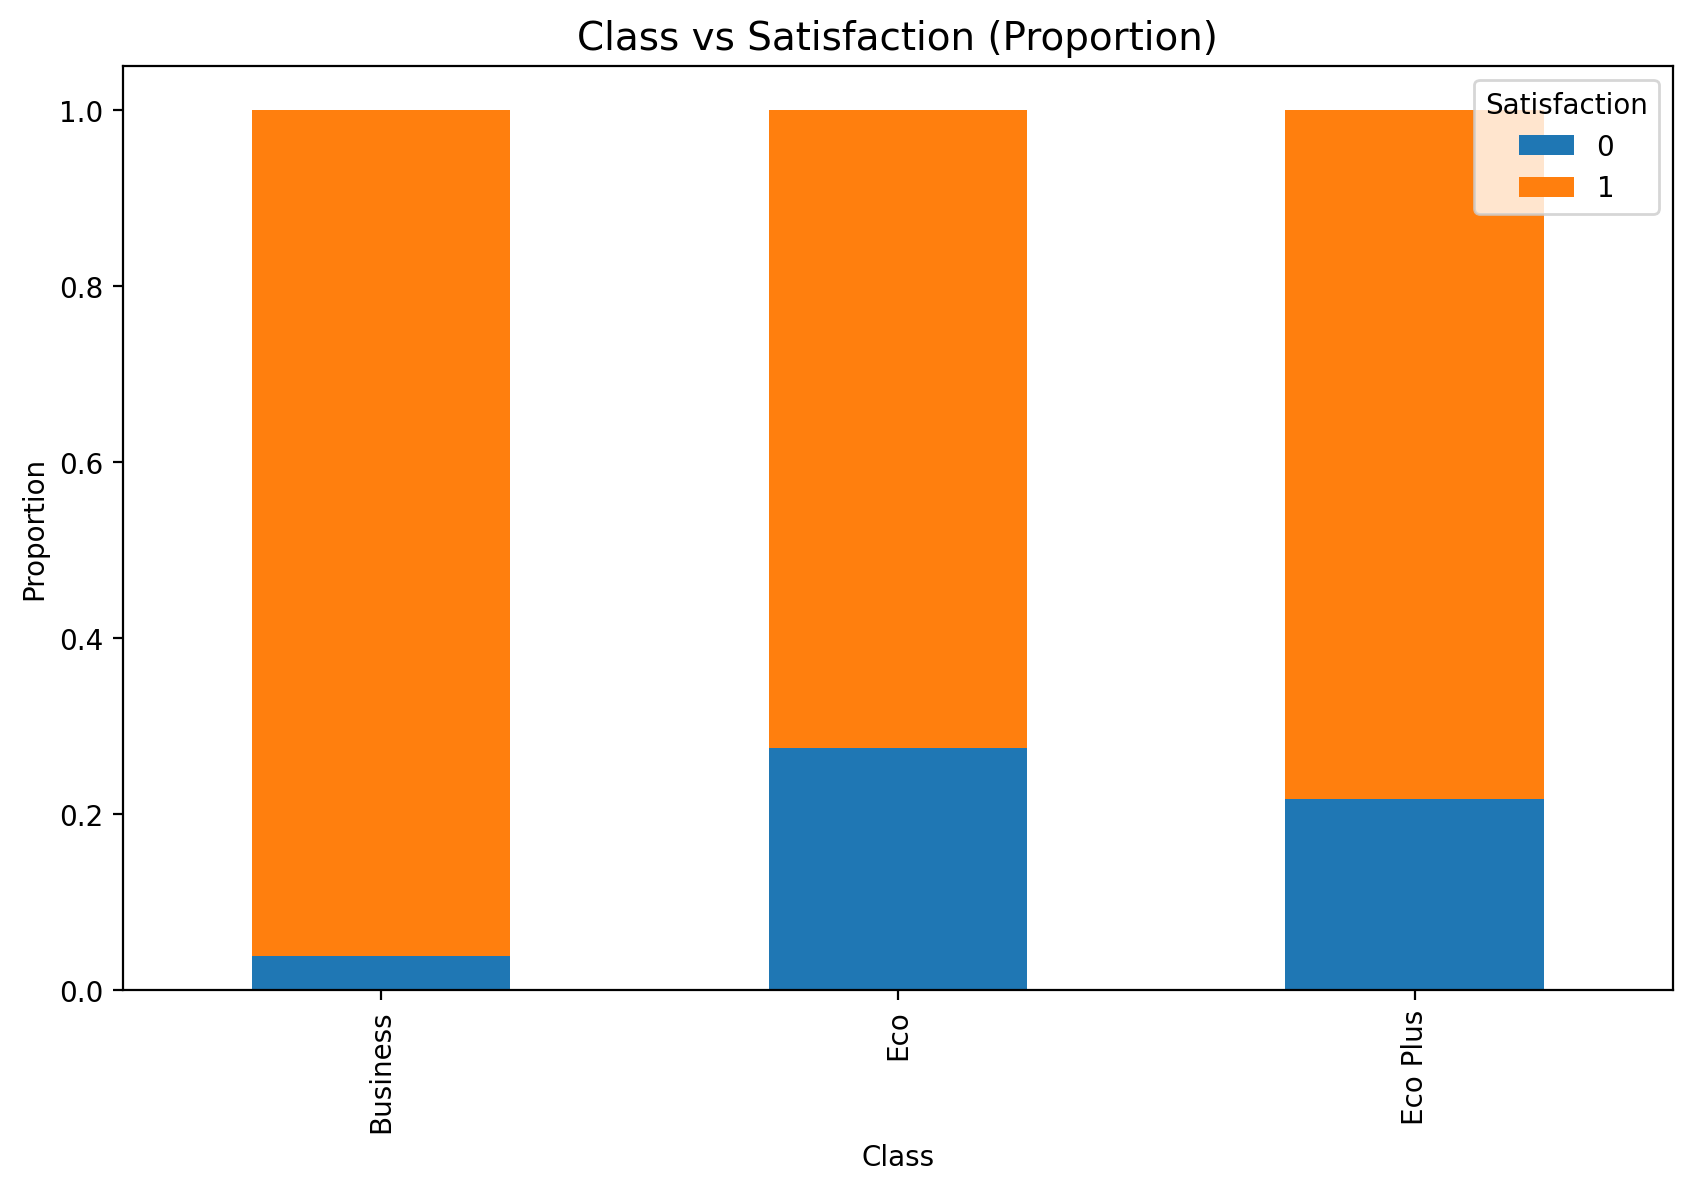

[Class 분석 결과]
P-value: 0.0000
결론: Class 등급에 따라 만족도 비율이 통계적으로 유의미하게 차이남.
------------------------------


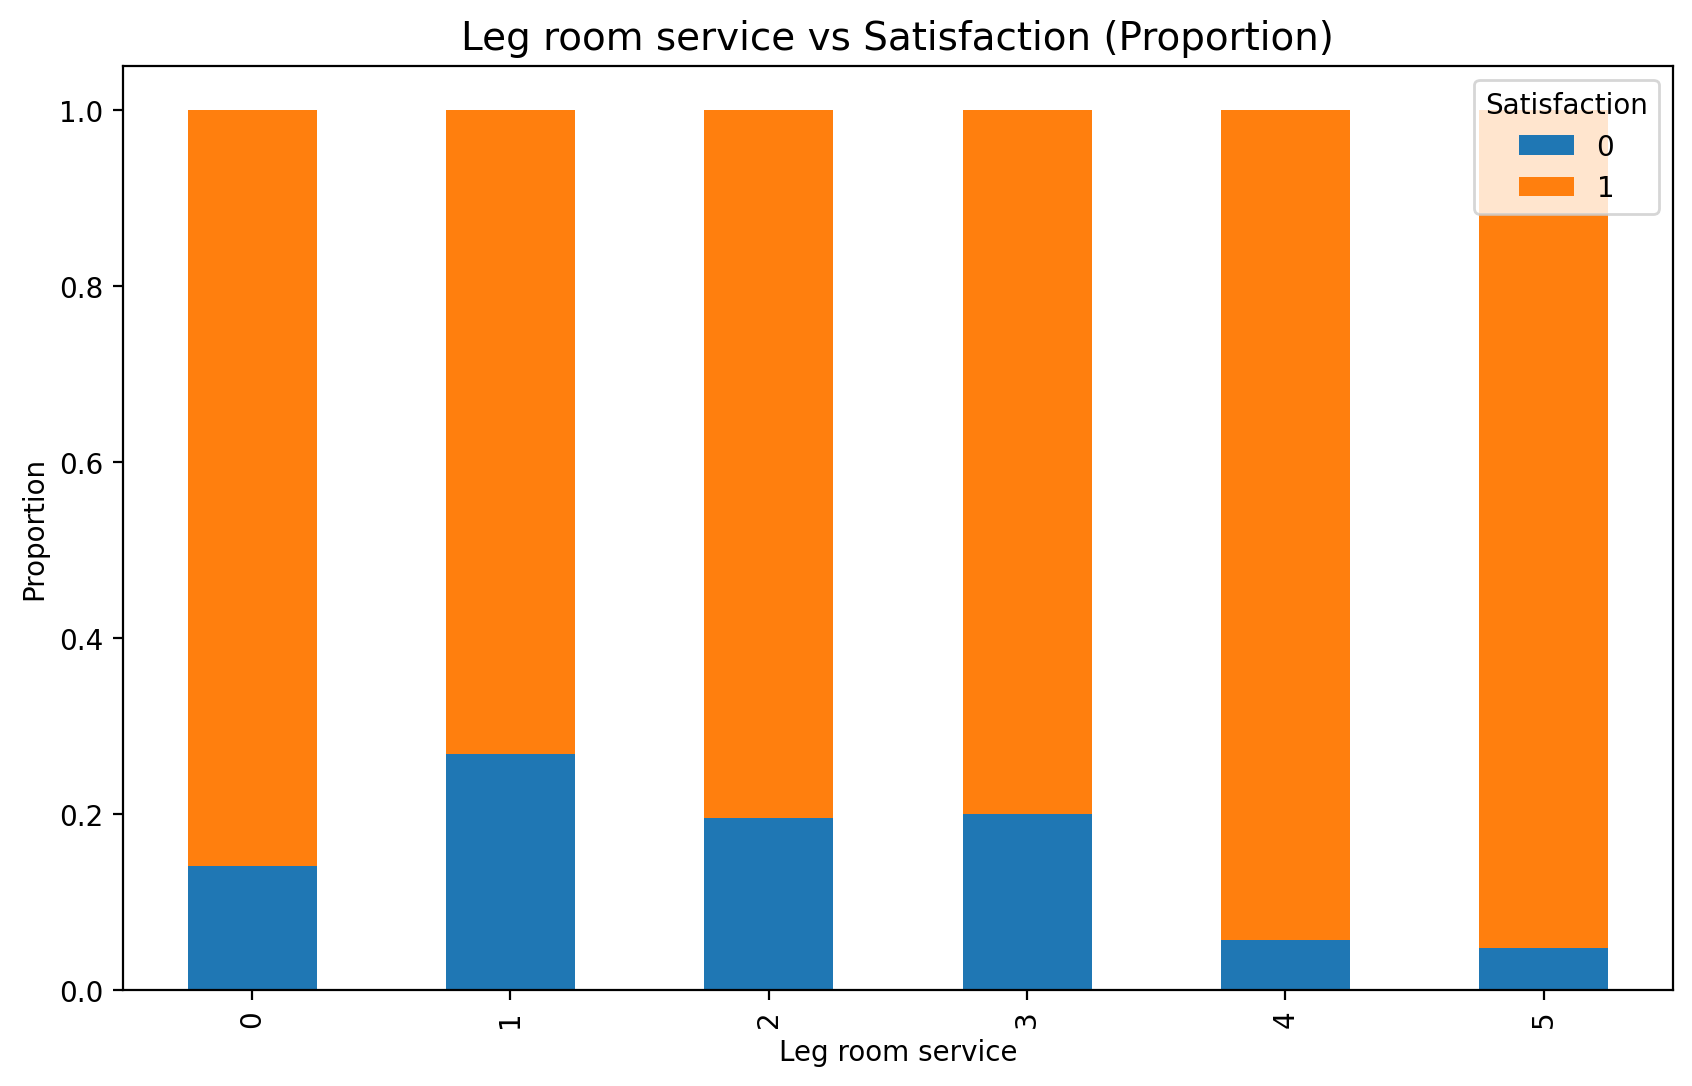

[Leg room service 분석 결과]
P-value: 0.0000
결론: Leg room service 등급에 따라 만족도 비율이 통계적으로 유의미하게 차이남.
------------------------------


In [10]:
from scipy.stats import chi2_contingency

# 분석할 변수 5개 리스트
features = ['Inflight wifi service', 'Online boarding', 'Ease of Online booking', 'Class', 'Leg room service']

for var in features:
    # 1. 교차표 생성
    table = pd.crosstab(data[var], data['Satisfaction'])

    # 2. 100% 비율로 변환 (핵심 수정 부분)
    # 각 행의 합으로 나눠서 모든 막대의 높이를 1로 맞춤
    table_prop = table.div(table.sum(1), axis=0)

    # 3. 시각화
    table_prop.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title(f'{var} vs Satisfaction (Proportion)', fontsize=14)
    plt.ylabel('Proportion')
    plt.legend(title='Satisfaction', loc='upper right')
    plt.show()

    # 4. 카이제곱 검정
    chi2, p, dof, expected = chi2_contingency(table)

    print(f"[{var} 분석 결과]")
    print(f"P-value: {p:.4f}")
    if p < 0.05:
        print(f"결론: {var} 등급에 따라 만족도 비율이 통계적으로 유의미하게 차이남.")
    print("-" * 30)

## **7. 저장하기**

- **to_csv()** 메서드를 사용해 이후 과정을 위해 data 데이터프레임을 **project01** 폴더에 저장합니다.
    - index=False 옵션 지정
    - data → path + 'data.csv'
    
- 저장된 파일을 필히 확인합니다.

In [ ]:
# 파일 저장
data.to_csv(path + 'data.csv', index=False)